Install packages

In [ ]:
# %pip install google-cloud-bigquery
# %pip install google-cloud-bigquery-storage
# %pip install pandas
# %pip install matplotlib
# %pip install seaborn
# %pip install db-dtypes
# %pip install scikit-learn
# %pip install xgboost
# %pip install optbinning




  Using cached optbinning-0.21.0-py3-none-any.whl.metadata (2.1 kB)
  Using cached ortools-9.11.4210-cp310-cp310-macosx_10_15_x86_64.whl.metadata (3.0 kB)
  Using cached ropwr-1.2.0-py3-none-any.whl.metadata (2.0 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached protobuf-5.26.1-cp37-abi3-macosx_10_9_universal2.whl.metadata (592 bytes)
  Using cached immutabledict-4.3.1-py3-none-any.whl.metadata (3.5 kB)
  Using cached cvxpy-1.7.5-cp310-cp310-macosx_10_9_x86_64.whl.metadata (9.5 kB)
  Using cached osqp-1.1.3-cp310-cp310-macosx_10_9_x86_64.whl.metadata (2.2 kB)
  Using cached clarabel-0.11.1-cp39-abi3-macosx_10_12_x86_64.whl.metadata (4.8 kB)
  Using cached scs-3.2.11-cp310-cp310-macosx_10_16_x86_64.whl
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached markupsafe-3.0.3-cp310-cp310-macosx_10_9_x86_64.whl.metadata (2.7 kB)
Using cached optbinning-0.21.0-py3-none-any.whl (214 kB)
Using cached ortools-9.11.4210-cp310-cp310-macosx_1

# 1. Import Libraries

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import os

os.environ.pop("GOOGLE_APPLICATION_CREDENTIALS", None)

from google.cloud import bigquery

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", None)
plt.style.use("ggplot")

# 2. Loading Data

## 2.1 Connection to Bigquery

Note that we've created tables intermediary tables in Bigquery that have our features, target variable and data quality. We'll connect to our Bigquery project then pull the relevant tables into dataframes

In [ ]:
PROJECT_ID = "credit-risk-modelling-499009"

client = bigquery.Client(project=PROJECT_ID)

Pulling features from Bigquery

In [4]:
features_sql = """ SELECT * FROM credit-risk-modelling-499009.staging_intermediate.intermediate_credit_risk_features """ 
features_df = client.query(features_sql).to_dataframe()

In [5]:
features_df.head()

,id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate_pct,installment,grade,sub_grade,purpose,application_type,emp_length_years,annual_inc,home_ownership,dti,fico_score,last_fico_score,delinq_2yrs,acc_now_delinq,inq_last_6mths,inq_last_12m,open_acc,total_acc,mort_acc,pub_rec,revol_bal,revol_util_pct,total_rev_hi_lim,tot_cur_bal,total_bc_limit,bc_util,all_util,issue_date,earliest_credit_line_date,credit_history_months,loan_to_income_ratio,installment_income_ratio,funded_to_income_ratio,fico_change,delinquency_flag,recent_inquiry_flag,high_utilization_flag,thin_file_flag,mortgage_flag,employment_stability_flag,fico_band,high_dti_flag,revolving_balance_ratio,balance_to_limit_ratio,subprime_flag
0,61554022,13300.0,13300.0,13300.0,14.650000000,458.78,C,C5,debt_consolidation,Individual,6,38200.0,RENT,24.66,667.0,657.0,0.0,0.0,0.0,NaN,9.0,12.0,0.0,0.0,5264.0,52.100000000,10100.0,22974.0,7300.0,69.5,NaN,2015-10-01,2007-06-01,100,0.348168,0.012010,0.348168,-10.0,0,0,0,0,0,1,Fair,0,0.521188,3.147123,0
1,137886914,13650.0,13650.0,13650.0,11.550000000,300.55,B,B4,debt_consolidation,Joint App,6,50000.0,MORTGAGE,1.83,752.0,737.0,0.0,0.0,0.0,3.0,6.0,11.0,4.0,0.0,2506.0,17.600000000,14200.0,237567.0,11500.0,21.8,18.0,2018-08-01,2004-12-01,164,0.273000,0.006011,0.273000,-15.0,0,0,0,0,1,1,Very Good,0,0.176479,20.658000,0
2,74222230,14000.0,14000.0,14000.0,11.470000000,307.69,B,B5,credit_card,Individual,2,32000.0,RENT,30.20,727.0,537.0,0.0,0.0,0.0,1.0,14.0,30.0,0.0,0.0,8380.0,29.200000000,28700.0,33704.0,16600.0,44.8,58.0,2016-03-01,2004-02-01,145,0.437500,0.009615,0.437500,-190.0,0,0,0,0,0,0,Good,0,0.291986,2.030361,0
3,34954840,14000.0,14000.0,14000.0,12.990000000,318.48,C,C2,debt_consolidation,Individual,10,45000.0,MORTGAGE,14.64,697.0,797.0,1.0,0.0,0.0,NaN,14.0,18.0,1.0,0.0,15211.0,54.300000000,28000.0,138143.0,25800.0,59.0,NaN,2014-11-01,1987-03-01,332,0.311111,0.007077,0.311111,100.0,1,0,0,0,1,1,Good,0,0.543250,5.354380,0
4,13116973,14000.0,14000.0,14000.0,14.640000000,330.42,C,C3,credit_card,Individual,2,55000.0,RENT,18.74,697.0,662.0,0.0,0.0,1.0,NaN,19.0,24.0,0.0,0.0,10628.0,70.400000000,15100.0,42342.0,8300.0,73.1,NaN,2014-04-01,2006-05-01,95,0.254545,0.006008,0.254545,-35.0,0,1,0,0,0,0,Good,0,0.703841,5.101446,0


Pulling our target feature from Bigquery

In [6]:
target_sql = """
SELECT *
FROM `credit-risk-modelling-499009.staging_intermediate.intermediate_default_target`
"""

target_df = client.query(target_sql).to_dataframe()

In [7]:
target_df.head()

,id,loan_status,default_flag
0,120654047,Current,0
1,130395508,Current,0
2,128210844,Current,0
3,145167263,Current,0
4,141637736,Current,0


Pulling quality table from Bigquery

In [8]:
quality_sql = """
SELECT *
FROM `credit-risk-modelling-499009.staging_intermediate.intermediate_feature_quality`
"""

quality_df = client.query(quality_sql).to_dataframe()

In [9]:
quality_df.head()

,total_records,missing_annual_income,missing_fico_score,missing_revol_utilization,missing_dti,missing_credit_history,missing_loan_income_ratio,missing_fico_change,avg_fico_score,avg_annual_income,avg_revol_utilization,avg_dti
0,2925492,4,0,2660,3108,29,3058,0,702.511133,79937.274015,48.986439375,19.29648


Joining features from Bigquery and target feature

In [10]:
df = features_df.merge(
    target_df[["id","default_flag"]],
    on="id",
    how="inner"
)

# 3. Dataset Overview

## 3.1 Dataset shape

Let's see how many rows and columns we have in our full dataset

In [11]:
print(df.shape)

(2925492, 50)


## 3.2 Data inspection

Below, we'll see data types for our features and we need to make sure our target variable is an integer and not a string

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2925492 entries, 0 to 2925491
Data columns (total 50 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   id                         object 
 1   loan_amnt                  float64
 2   funded_amnt                float64
 3   funded_amnt_inv            float64
 4   int_rate_pct               object 
 5   installment                float64
 6   grade                      object 
 7   sub_grade                  object 
 8   purpose                    object 
 9   application_type           object 
 10  emp_length_years           Int64  
 11  annual_inc                 float64
 12  home_ownership             object 
 13  dti                        float64
 14  fico_score                 float64
 15  last_fico_score            float64
 16  delinq_2yrs                float64
 17  acc_now_delinq             float64
 18  inq_last_6mths             float64
 19  inq_last_12m               float64
 20  op

We'll do some more inspection below so we can make sure we have the required minimum values and we can also see some statistical values

In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
loan_amnt,2925492.0,15358.775105,9478.383451,500.0,8000.0,13000.0,20000.0,40000.0
funded_amnt,2925492.0,15354.704909,9477.144689,500.0,8000.0,13000.0,20000.0,40000.0
funded_amnt_inv,2925492.0,15340.046287,9480.634495,0.0,8000.0,13000.0,20000.0,40000.0
installment,2925492.0,452.391358,272.947849,4.93,253.5,382.3,603.92,1719.83
emp_length_years,2720272.0,5.827143,3.752518,0.0,2.0,6.0,10.0,10.0
annual_inc,2925488.0,79937.274015,111747.60871,0.0,47000.0,66000.0,95000.0,110000000.0
dti,2922384.0,19.29648,15.719773,-1.0,12.08,18.1,24.88,999.0
fico_score,2925492.0,702.511133,33.766092,612.0,677.0,697.0,722.0,847.5
last_fico_score,2925492.0,684.109485,90.890603,0.0,652.0,697.0,737.0,847.5
delinq_2yrs,2925463.0,0.289701,0.843682,0.0,0.0,0.0,0.0,58.0


later, we'll need to consider the values where dti is negative

# 4. Target Variable Analysis

## Objective

The target variable represents the outcome that the model is trying to predict.

In this project, the target is:

- default_flag = 1: Borrower defaulted,
- default_flag = 0: Borrower did not default.

Before building any predictive model, we need to understand the distribution of the target variable. Specifically, we want to answer the following questions:

- Is the dataset balanced or imbalanced?
- What proportion of borrowers default?
- Will class imbalance influence model training?
- Which evaluation metrics should be used?

Understanding these characteristics helps determine whether additional techniques such as class weighting or resampling may be required during model development.

## 4.1 Verifying the Target Variable

Before analysing the target, ensure it contains only the expected binary values.

In [14]:
# Check unique target values
print("Unique target values:")
print(df["default_flag"].unique())

# Check data type
print("\nData type:")
print(df["default_flag"].dtype)

Unique target values:
<IntegerArray>
[0, 1]
Length: 2, dtype: Int64

Data type:
Int64


## 4.2 Class Counts

Check the number of defaulted and non-defaulted loans and also check out some visuals

In [15]:
df.default_flag.value_counts()

default_flag
0    2545596
1     379896
Name: count, dtype: Int64

## 4.3 Class Distribution (%)

Absolute counts alone can be misleading for large datasets, so calculate the class proportions.

In [16]:
df.default_flag.value_counts(normalize=True)

default_flag
0    0.870143
1    0.129857
Name: proportion, dtype: Float64

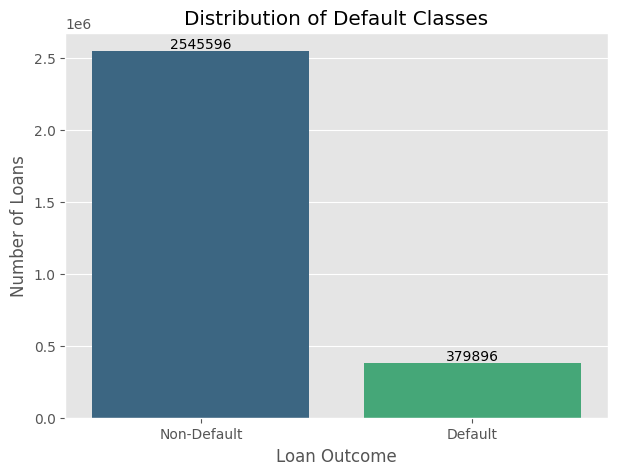

In [17]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x="default_flag",
    palette="viridis"
)

ax.set_xticklabels(["Non-Default", "Default"])

plt.title("Distribution of Default Classes")
plt.xlabel("Loan Outcome")
plt.ylabel("Number of Loans")

# Add labels above each bar
for container in ax.containers:
    ax.bar_label(container, fmt="%d")

plt.show()

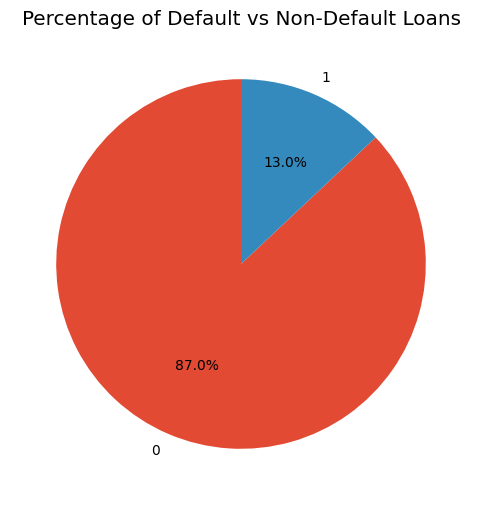

In [18]:
plt.figure(figsize=(6, 6))

(
    df["default_flag"]
    .value_counts()
    .plot(
        kind="pie",
        autopct="%1.1f%%",
        startangle=90
    )
)

plt.ylabel("")
plt.title("Percentage of Default vs Non-Default Loans")

plt.show()

## 4.6 Class Imbalance Ratio

Calculate the imbalance ratio. The imbalance ratio helps assess whether the minority class is underrepresented.

| Ratio  | Interpretation     |
| ------ | ------------------ |
| 1:1    | Balanced           |
| 2–5:1  | Mild imbalance     |
| 5–10:1 | Moderate imbalance |
| >10:1  | Severe imbalance   |


In [19]:
majority = df["default_flag"].value_counts().max()
minority = df["default_flag"].value_counts().min()

imbalance_ratio = round(majority / minority, 2)

print(f"Class Imbalance Ratio: {imbalance_ratio}:1")

Class Imbalance Ratio: 6.7:1


## 4.7 Findings

After running the analysis above, we can conclude that our target variable is correctly categorized as 0 or 1. The modelling dataset contains a substantially larger proportion of non-defaulted loans than defaulted loans, which is expected in consumer lending portfolios. The default rate represents the baseline probability of default within the dataset.

The observed class imbalance is moderate and reflects real-world lending behaviour rather than a data quality issue. To preserve this distribution during model development, stratified train, validation, and test splits will be used. Model performance will primarily be assessed using ROC-AUC, Gini, KS Statistic, and Precision-Recall metrics rather than overall accuracy, as accuracy can be misleading on imbalanced datasets.

We'll not resample yet because for **Probability of Default (PD) scorecards**, the objective is to estimate the true probability of default. Artificially changing the class distribution can distort probability calibration and make the model less representative of the actual portfolio.

# 5. Missing value analysis

## Objective

Missing values are common in consumer lending data due to:

- Incomplete loan applications
- Differences in borrower profiles
- Changes in reporting requirements over time
- Fields that are only applicable to certain borrowers

Before imputing missing values, we first need to answer the following questions:

- Which variables contain missing values?
- How much information is missing?
- Is the missingness likely to affect model performance?
- Can the missing values be explained by other borrower characteristics?
- What is the most appropriate imputation strategy for each variable?

The answers to these questions determine the preprocessing pipeline that will later be used for model training.

## 5.1 Missing Value Summary

First, we'll calculate the number and percentage of missing values for each feature. This will help understand which variables require special attention.

In [20]:
missing_summary = (
    pd.DataFrame({
        "Missing Count": df.isna().sum(),
        "Missing %": (df.isna().mean() * 100)
    })
    .sort_values("Missing %", ascending=False)
)

missing_summary

,Missing Count,Missing %
all_util,866485,29.618437
inq_last_12m,866130,29.606302
emp_length_years,205220,7.014888
balance_to_limit_ratio,103124,3.525014
bc_util,84141,2.876132
revolving_balance_ratio,72364,2.473567
tot_cur_bal,70276,2.402194
total_rev_hi_lim,70276,2.402194
mort_acc,50030,1.710140
total_bc_limit,50030,1.710140


In [21]:
def classify_missingness(pct):
    if pct == 0:
        return "Complete"
    elif pct < 5:
        return "Low"
    elif pct < 20:
        return "Moderate"
    else:
        return "High"

missing_summary["Missing Level"] = (
    missing_summary["Missing %"]
    .apply(classify_missingness)
)

missing_summary

,Missing Count,Missing %,Missing Level
all_util,866485,29.618437,High
inq_last_12m,866130,29.606302,High
emp_length_years,205220,7.014888,Moderate
balance_to_limit_ratio,103124,3.525014,Low
bc_util,84141,2.876132,Low
revolving_balance_ratio,72364,2.473567,Low
tot_cur_bal,70276,2.402194,Low
total_rev_hi_lim,70276,2.402194,Low
mort_acc,50030,1.710140,Low
total_bc_limit,50030,1.710140,Low


Let's visualize the missing values. Visuals help us identify patterns much easier.

<Axes: >

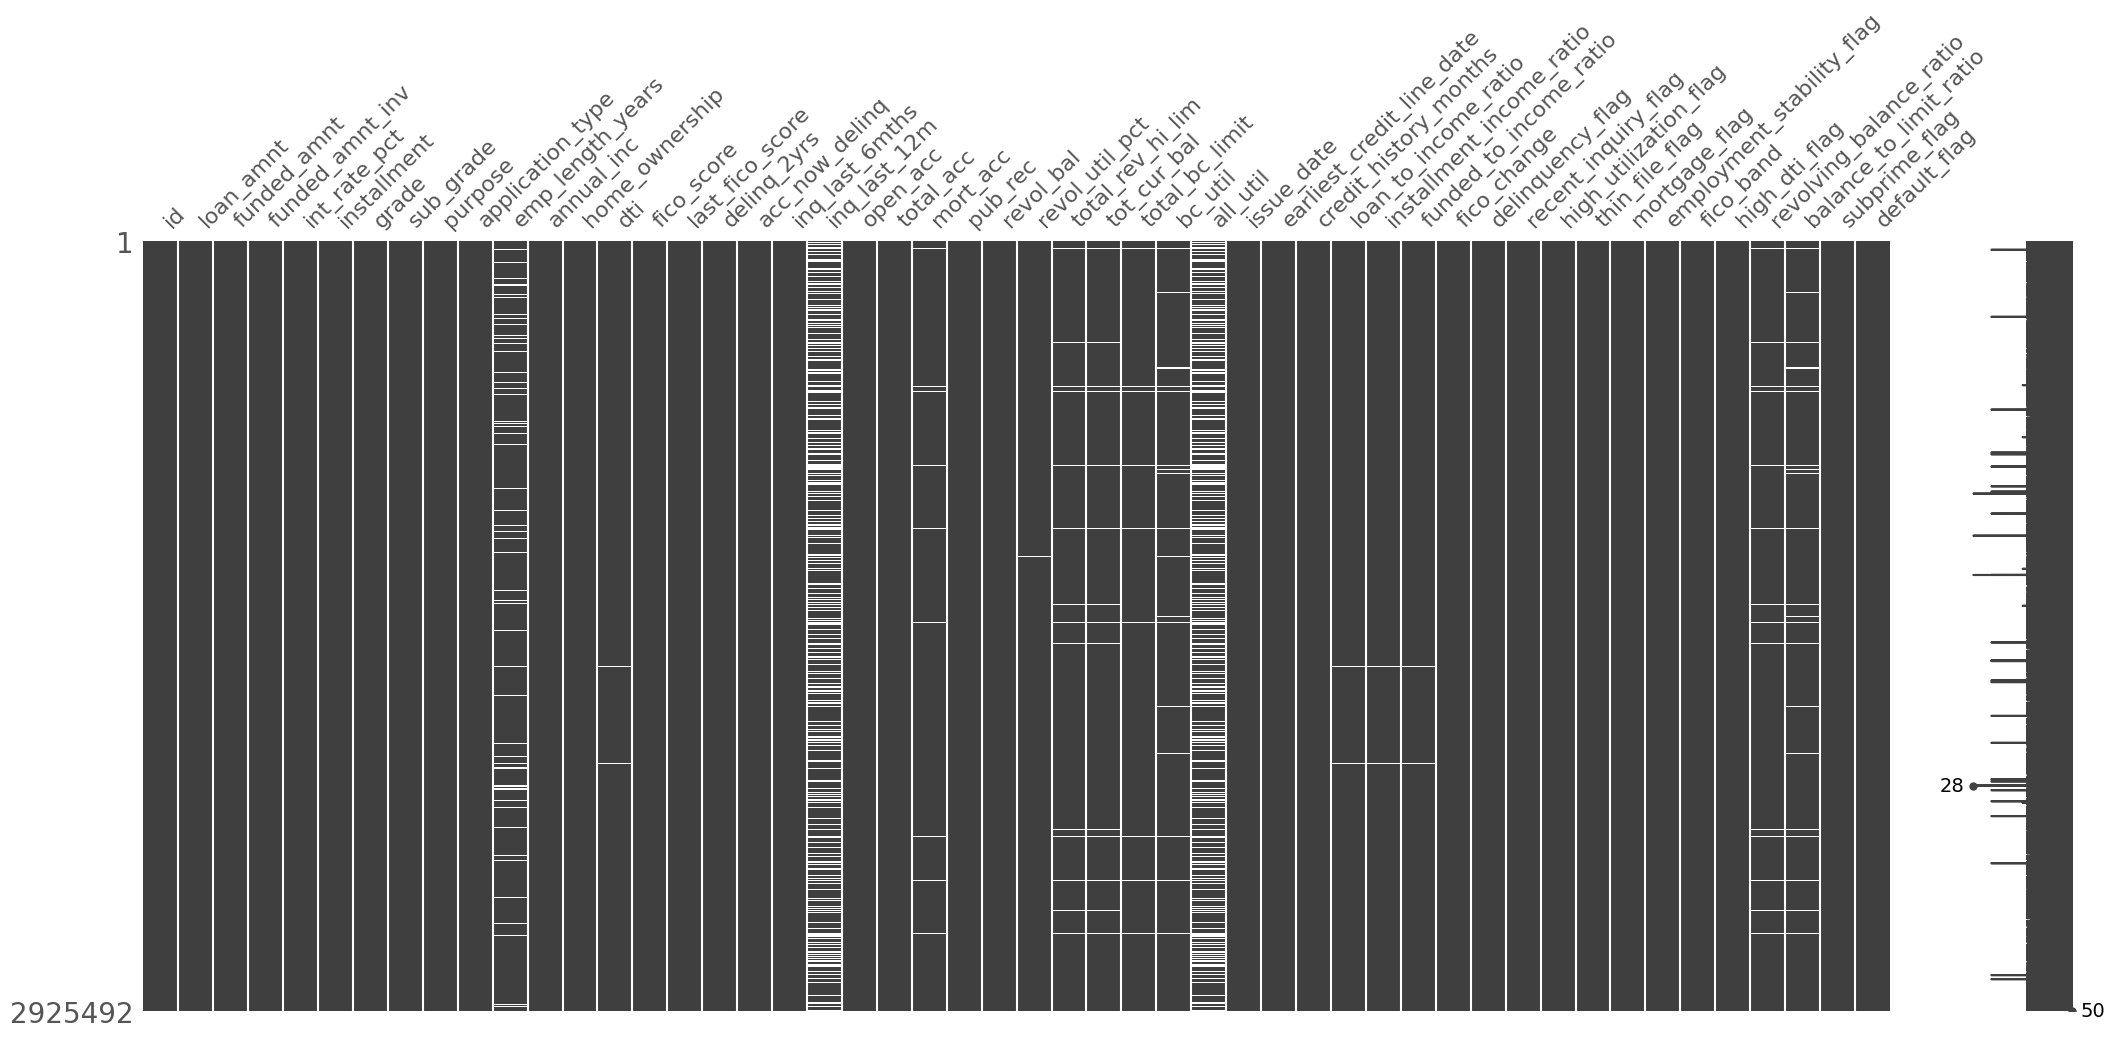

In [22]:
# %pip install missingno
import missingno as msno

msno.matrix(df)

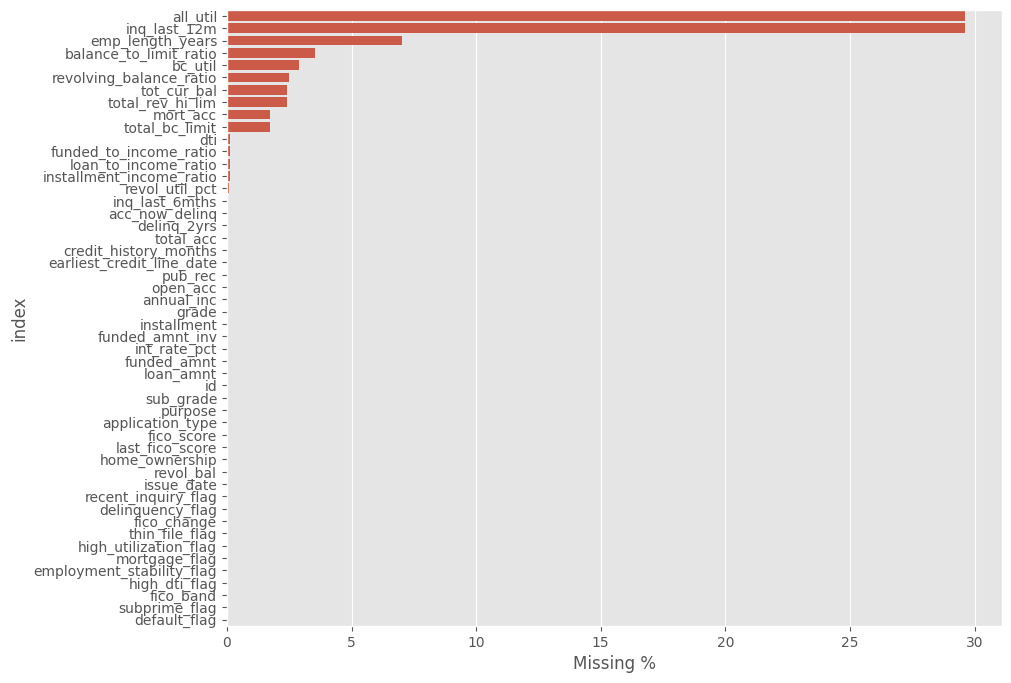

In [23]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=missing_summary.reset_index(),
    y="index",
    x="Missing %"
)

plt.show()

Features to impute

In [24]:
features_to_impute = (
    missing_summary[
        missing_summary["Missing Count"] > 0
    ]
)

features_to_impute

,Missing Count,Missing %,Missing Level
all_util,866485,29.618437,High
inq_last_12m,866130,29.606302,High
emp_length_years,205220,7.014888,Moderate
balance_to_limit_ratio,103124,3.525014,Low
bc_util,84141,2.876132,Low
revolving_balance_ratio,72364,2.473567,Low
tot_cur_bal,70276,2.402194,Low
total_rev_hi_lim,70276,2.402194,Low
mort_acc,50030,1.710140,Low
total_bc_limit,50030,1.710140,Low


We will not drop any missing values but we will use imputation strategies to add the missing values. We will impute the values later in the notebook since we first need to get some more info on our variables.

## 5.2 Missing Values by Target

For each feature with missing values, we'll compare the default rate between observations with and without missing values. Features, we'll focus on are the ones with high missing level

In [25]:
def missing_default_rate(df, feature, target="default_flag"):
    summary = (
        df.assign(is_missing=df[feature].isna())
          .groupby("is_missing")[target]
          .agg(
              observations="count",
              default_rate="mean"
          )
    )

    return summary

In [26]:
missing_features = missing_summary[
    missing_summary["Missing Count"] > 0
].index

for feature in missing_features:
    print(f"\n{'='*60}")
    print(feature)
    print(missing_default_rate(df, feature))


all_util
            observations  default_rate
is_missing                            
False            2059007      0.109789
True              866485      0.177545

inq_last_12m
            observations  default_rate
is_missing                            
False            2059362      0.109785
True              866130      0.177581

emp_length_years
            observations  default_rate
is_missing                            
False            2720272      0.127651
True              205220      0.159098

balance_to_limit_ratio
            observations  default_rate
is_missing                            
False            2822368      0.129122
True              103124      0.149965

bc_util
            observations  default_rate
is_missing                            
False            2841351      0.129399
True               84141      0.145316

revolving_balance_ratio
            observations  default_rate
is_missing                            
False            2853128      0.129189
Tru

From the above, we can see that there is minor differences between missing values default rate and observed values. We'll keep the features and not drop any and we'll carefully handle them later.

## 5.3 Investigating Relationships for Imputation

We'll now investigate whether missing values can be estimated from related borrower characteristics.

In [27]:
df.groupby("fico_band")["all_util"].describe()


,count,mean,std,min,25%,50%,75%,max
fico_band,,,,,,,,
Exceptional,36155.0,26.229457,16.208289,0.0,14.0,25.0,37.0,107.0
Fair,288094.0,65.312030,19.268411,0.0,53.0,67.0,78.0,216.0
Good,1446612.0,58.385499,19.327015,0.0,46.0,59.0,72.0,239.0
Very Good,288146.0,40.440155,18.220990,0.0,28.0,40.0,52.0,158.0


In [28]:
df.groupby("fico_band")["inq_last_12m"].describe()

,count,mean,std,min,25%,50%,75%,max
fico_band,,,,,,,,
Exceptional,36162.0,1.188070,1.593746,0.0,0.0,1.0,2.0,27.0
Fair,288135.0,2.398306,2.680368,0.0,1.0,2.0,3.0,46.0
Good,1446818.0,2.009248,2.350034,0.0,0.0,1.0,3.0,67.0
Very Good,288247.0,1.668777,2.009134,0.0,0.0,1.0,2.0,35.0


In [29]:
df.groupby("grade")["emp_length_years"].describe()

,count,mean,std,min,25%,50%,75%,max
grade,,,,,,,,
A,611503.0,5.822305,3.78091,0.0,2.0,6.0,10.0,10.0
B,797047.0,5.849734,3.749834,0.0,2.0,6.0,10.0,10.0
C,745612.0,5.798858,3.750339,0.0,2.0,6.0,10.0,10.0
D,385016.0,5.789193,3.739102,0.0,2.0,6.0,10.0,10.0
E,130100.0,5.916172,3.710245,0.0,2.0,6.0,10.0,10.0
F,39471.0,6.024271,3.673875,0.0,3.0,6.0,10.0,10.0
G,11523.0,5.938992,3.706374,0.0,2.0,6.0,10.0,10.0


The dataset is generally of high quality, with most variables containing less than 3% missing values. Two variables (all_util and inq_last_12m) exhibit approximately 30% missingness and will be retained pending evaluation of their predictive value during Information Value analysis. Rather than applying global mean imputation, continuous variables will be imputed using group-specific means based on related application characteristics such as grade, fico_band, and home_ownership. This approach better preserves the underlying borrower distributions and is expected to reduce imputation bias. Categorical variables will retain an explicit "Missing" category where applicable, allowing the subsequent WoE transformation to estimate whether missingness itself is predictive of default.

# 6. Numerical feature analysis

## Objective

Numerical features represent continuous or discrete measurements describing a borrower's financial profile, credit history, and loan characteristics.

Before building a credit risk model, we need to understand the statistical behaviour of these variables.

Specifically, we want to answer the following questions:

- What does the distribution of each variable look like?
- Are the variables normally distributed or highly skewed?
- Are there obvious outliers?
- Should any variables be transformed before modelling?
- Do the distributions differ between defaulted and non-defaulted borrowers?

These insights will guide later preprocessing steps such as winsorization, logarithmic transformation, WoE binning, and feature selection.

In [30]:
# Select numeric features 

numeric_features = df.select_dtypes(
    include=["number"]
).columns.tolist()

# Exclude the target variable
numeric_features.remove("default_flag")

print(f"Number of numerical features: {len(numeric_features)}")
numeric_features

Number of numerical features: 38


['loan_amnt',
 'funded_amnt',
 'funded_amnt_inv',
 'installment',
 'emp_length_years',
 'annual_inc',
 'dti',
 'fico_score',
 'last_fico_score',
 'delinq_2yrs',
 'acc_now_delinq',
 'inq_last_6mths',
 'inq_last_12m',
 'open_acc',
 'total_acc',
 'mort_acc',
 'pub_rec',
 'revol_bal',
 'total_rev_hi_lim',
 'tot_cur_bal',
 'total_bc_limit',
 'bc_util',
 'all_util',
 'credit_history_months',
 'loan_to_income_ratio',
 'installment_income_ratio',
 'funded_to_income_ratio',
 'fico_change',
 'delinquency_flag',
 'recent_inquiry_flag',
 'high_utilization_flag',
 'thin_file_flag',
 'mortgage_flag',
 'employment_stability_flag',
 'high_dti_flag',
 'revolving_balance_ratio',
 'balance_to_limit_ratio',
 'subprime_flag']

## 6.1 Summary Statistics

Generate descriptive statistics for all numerical variables.

In [31]:
summary_stats = (
    df[numeric_features]
    .describe()
    .T
)

summary_stats

,count,mean,std,min,25%,50%,75%,max
loan_amnt,2925492.0,15358.775105,9478.383451,500.0,8000.0,13000.0,20000.0,40000.0
funded_amnt,2925492.0,15354.704909,9477.144689,500.0,8000.0,13000.0,20000.0,40000.0
funded_amnt_inv,2925492.0,15340.046287,9480.634495,0.0,8000.0,13000.0,20000.0,40000.0
installment,2925492.0,452.391358,272.947849,4.93,253.5,382.3,603.92,1719.83
emp_length_years,2720272.0,5.827143,3.752518,0.0,2.0,6.0,10.0,10.0
annual_inc,2925488.0,79937.274015,111747.60871,0.0,47000.0,66000.0,95000.0,110000000.0
dti,2922384.0,19.29648,15.719773,-1.0,12.08,18.1,24.88,999.0
fico_score,2925492.0,702.511133,33.766092,612.0,677.0,697.0,722.0,847.5
last_fico_score,2925492.0,684.109485,90.890603,0.0,652.0,697.0,737.0,847.5
delinq_2yrs,2925463.0,0.289701,0.843682,0.0,0.0,0.0,0.0,58.0


In [32]:
summary_stats["missing"] = df[numeric_features].isna().sum()
summary_stats["missing_pct"] = (
    df[numeric_features].isna().mean() * 100
)

summary_stats["median"] = df[numeric_features].median()
summary_stats["skewness"] = df[numeric_features].skew()

summary_stats = summary_stats[
    [
        "count",
        "missing",
        "missing_pct",
        "mean",
        "median",
        "std",
        "min",
        "25%",
        "50%",
        "75%",
        "max",
        "skewness"
    ]
]

summary_stats

,count,missing,missing_pct,mean,median,std,min,25%,50%,75%,max,skewness
loan_amnt,2925492.0,0,0.000000,15358.775105,13000.0,9478.383451,500.0,8000.0,13000.0,20000.0,40000.0,0.781375
funded_amnt,2925492.0,0,0.000000,15354.704909,13000.0,9477.144689,500.0,8000.0,13000.0,20000.0,40000.0,0.78216
funded_amnt_inv,2925492.0,0,0.000000,15340.046287,13000.0,9480.634495,0.0,8000.0,13000.0,20000.0,40000.0,0.781769
installment,2925492.0,0,0.000000,452.391358,382.3,272.947849,4.93,253.5,382.3,603.92,1719.83,0.98972
emp_length_years,2720272.0,205220,7.014888,5.827143,6.0,3.752518,0.0,2.0,6.0,10.0,10.0,-0.16455
annual_inc,2925488.0,4,0.000137,79937.274015,66000.0,111747.60871,0.0,47000.0,66000.0,95000.0,110000000.0,399.824566
dti,2922384.0,3108,0.106239,19.29648,18.1,15.719773,-1.0,12.08,18.1,24.88,999.0,27.834598
fico_score,2925492.0,0,0.000000,702.511133,697.0,33.766092,612.0,677.0,697.0,722.0,847.5,1.114457
last_fico_score,2925492.0,0,0.000000,684.109485,697.0,90.890603,0.0,652.0,697.0,737.0,847.5,-2.050431
delinq_2yrs,2925463.0,29,0.000991,0.289701,0.0,0.843682,0.0,0.0,0.0,0.0,58.0,6.105346


The table above immediately reveals:

- variables with missing values,
- highly skewed features,
- unusually large ranges,
- potential data quality issues,
- variables that may require transformation.

## 6.2 Classify Feature Skewness

Highly skewed variables often benefit from transformation before modelling.

In [33]:
def classify_skewness(value):

    abs_value = abs(value)

    if abs_value < 0.5:
        return "Approximately Symmetric"

    elif abs_value < 1:
        return "Moderately Skewed"

    else:
        return "Highly Skewed"


summary_stats["distribution"] = (
    summary_stats["skewness"]
    .apply(classify_skewness)
)

summary_stats.sort_values(
    "skewness",
    ascending=False
)

,count,missing,missing_pct,mean,median,std,min,25%,50%,75%,max,skewness,distribution
installment_income_ratio,2922434.0,3058,0.104529,0.035983,0.005895,29.45269,0.000005,0.003759,0.005895,0.008736,50109.0,1685.376439,Highly Skewed
loan_to_income_ratio,2922434.0,3058,0.104529,1.163566,0.2,883.405315,0.000161,0.123853,0.2,0.299319,1500000.0,1675.590967,Highly Skewed
funded_to_income_ratio,2922434.0,3058,0.104529,1.163508,0.2,883.405315,0.000161,0.12381,0.2,0.299145,1500000.0,1675.590967,Highly Skewed
annual_inc,2925488.0,4,0.000137,79937.274015,66000.0,111747.60871,0.0,47000.0,66000.0,95000.0,110000000.0,399.824566,Highly Skewed
subprime_flag,2925492.0,0,0.000000,0.000167,0.0,0.012928,0.0,0.0,0.0,0.0,1.0,77.327922,Highly Skewed
dti,2922384.0,3108,0.106239,19.29648,18.1,15.719773,-1.0,12.08,18.1,24.88,999.0,27.834598,Highly Skewed
acc_now_delinq,2925463.0,29,0.000991,0.00323,0.0,0.061429,0.0,0.0,0.0,0.0,14.0,25.924868,Highly Skewed
balance_to_limit_ratio,2822368.0,103124,3.525014,11.846254,4.61898,34.862069,0.0,1.708377,4.61898,11.45106,7972.176667,25.528458,Highly Skewed
total_rev_hi_lim,2855216.0,70276,2.402194,36338.643163,26800.0,37309.898504,0.0,15400.0,26800.0,45600.0,9999999.0,24.915043,Highly Skewed
revol_bal,2925492.0,0,0.000000,16964.840934,11493.0,22996.213652,0.0,5993.0,11493.0,20644.0,2904836.0,11.908126,Highly Skewed


Financial variables such as income and balances are typically right-skewed and may later benefit from logarithmic transformation.

**Histogram Function**

Instead of plotting variables individually, create a reusable function.

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns


def plot_distribution(df, column):

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(14,5)
    )

    sns.histplot(
        data=df,
        x=column,
        bins=40,
        kde=True,
        ax=axes[0]
    )

    axes[0].set_title(f"{column} Distribution")

    sns.boxplot(
        x=df[column],
        ax=axes[1]
    )

    axes[1].set_title(f"{column} Boxplot")

    plt.tight_layout()

    plt.show()

Displaying the histogram and boxplot together allows us to assess:

- distribution shape,
- skewness,
- extreme observations,
- spread.

We'll focus first on the variables most relevant to credit risk.

In [35]:
key_numeric_features = [

    "annual_inc",

    "loan_amnt",

    "funded_amnt",

    "installment",

    "dti",

    "fico_score",

    "last_fico_score",

    "revol_bal",

    "revol_util_pct",

    "bc_util",

    "credit_history_months",

    "loan_to_income_ratio",

    "balance_to_limit_ratio",

    "revolving_balance_ratio"

]

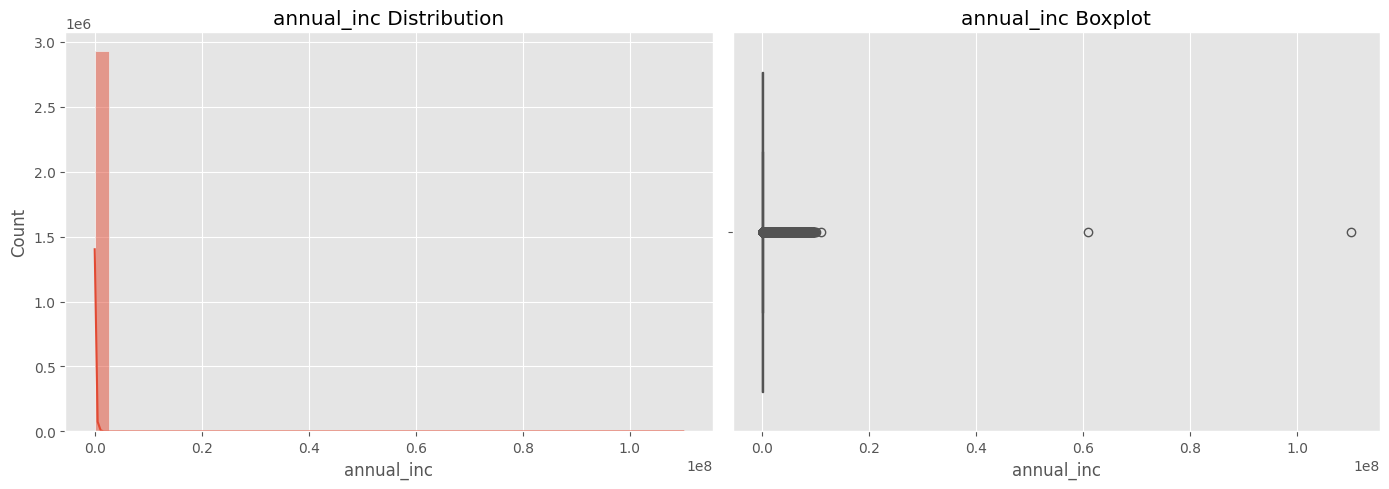

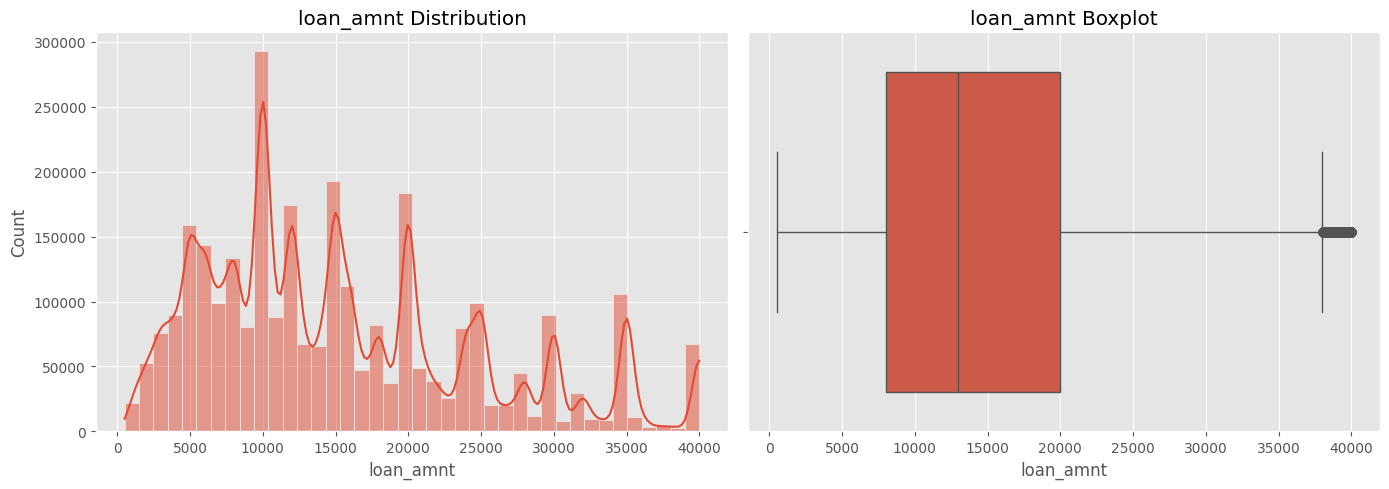

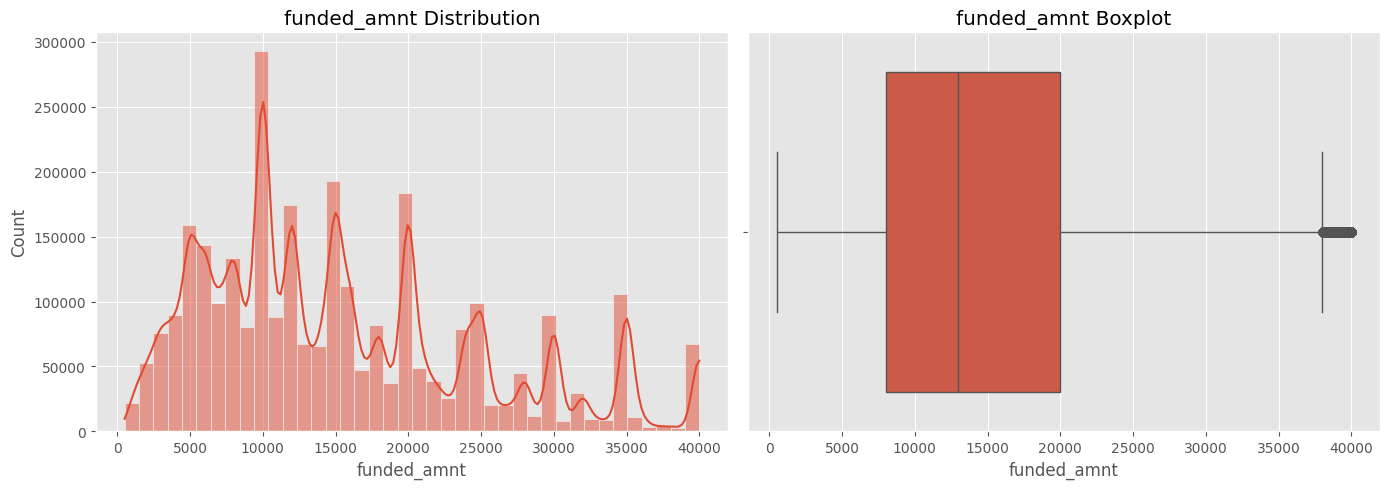

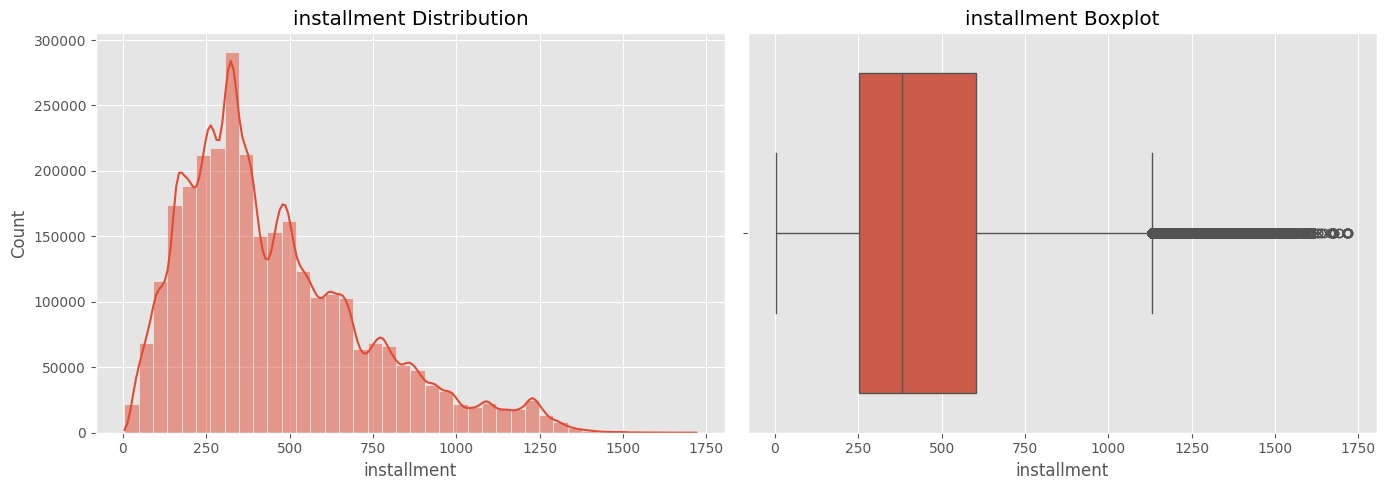

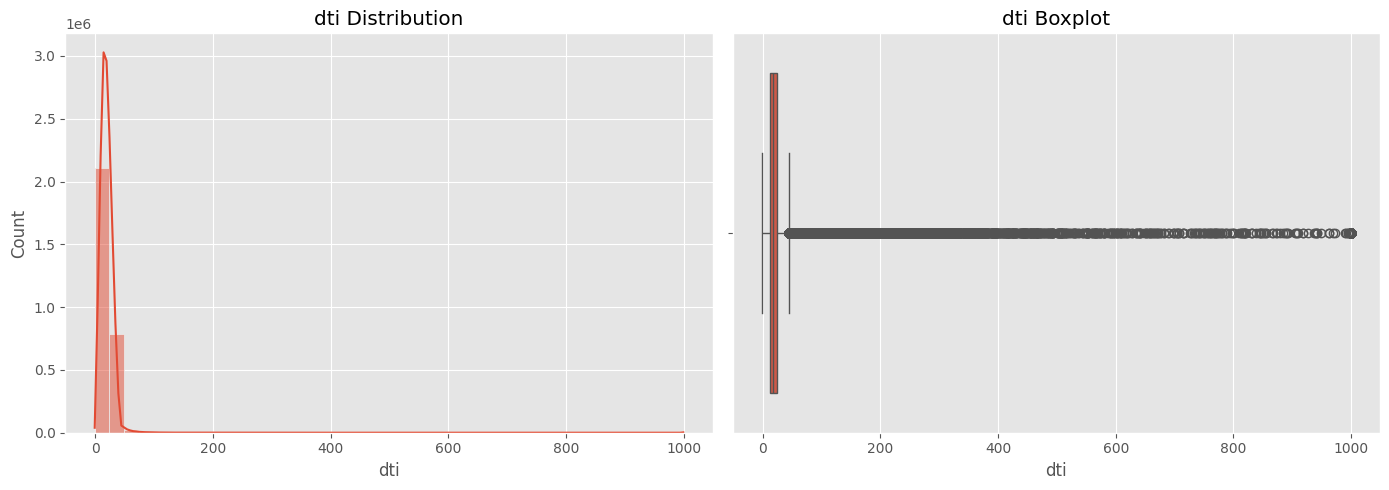

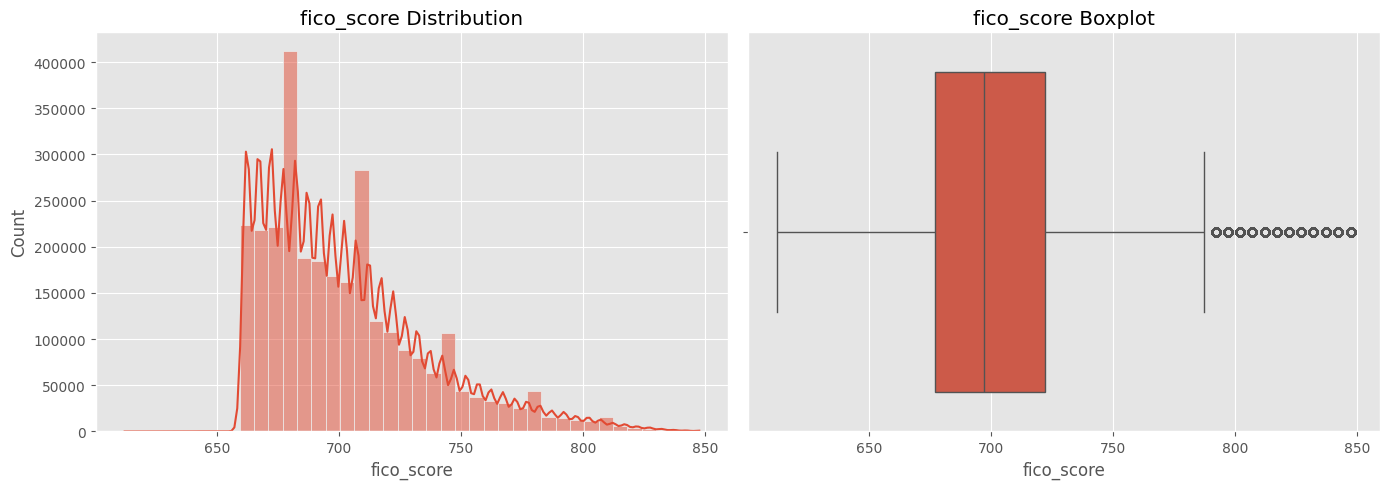

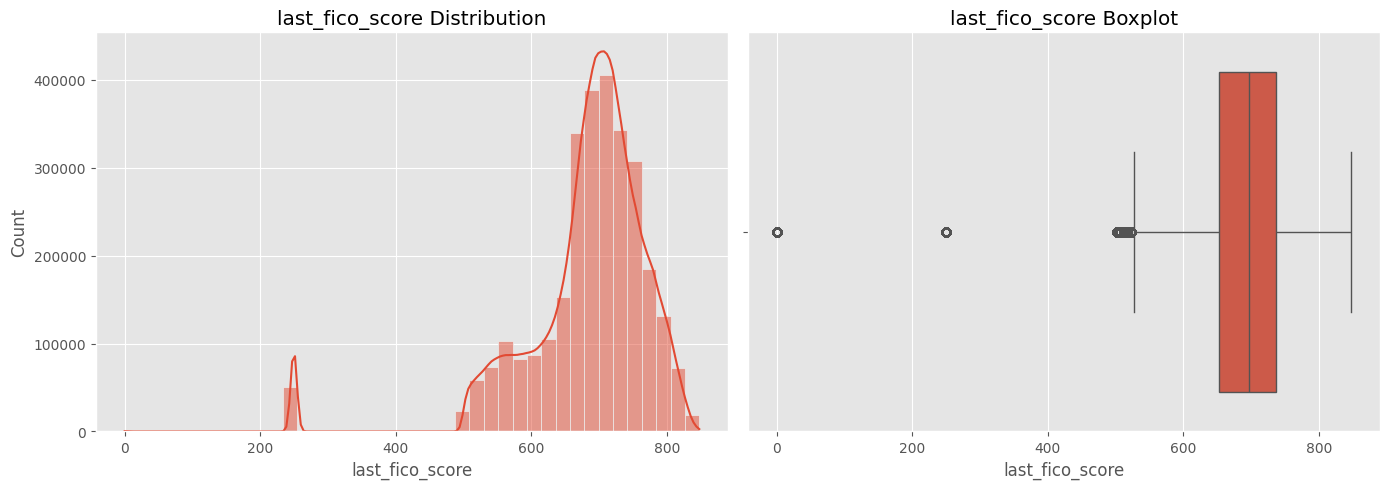

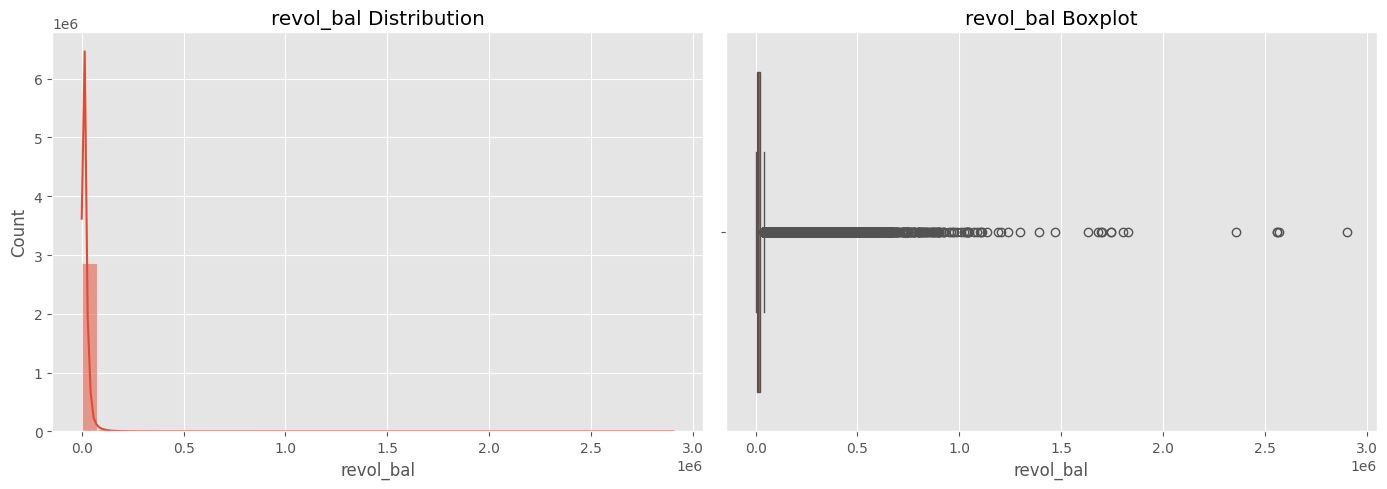

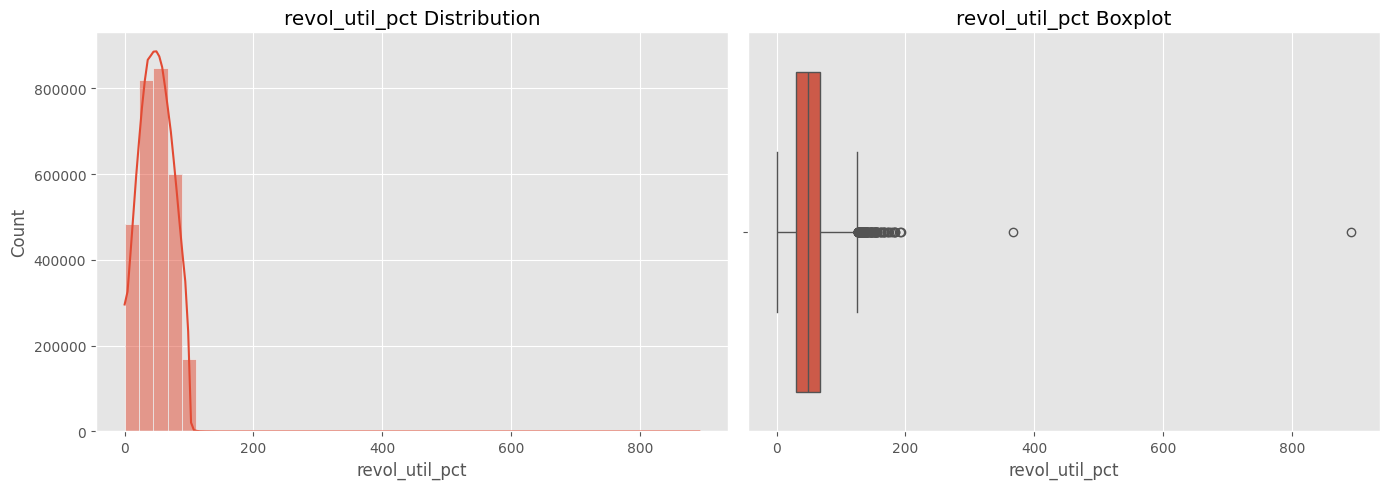

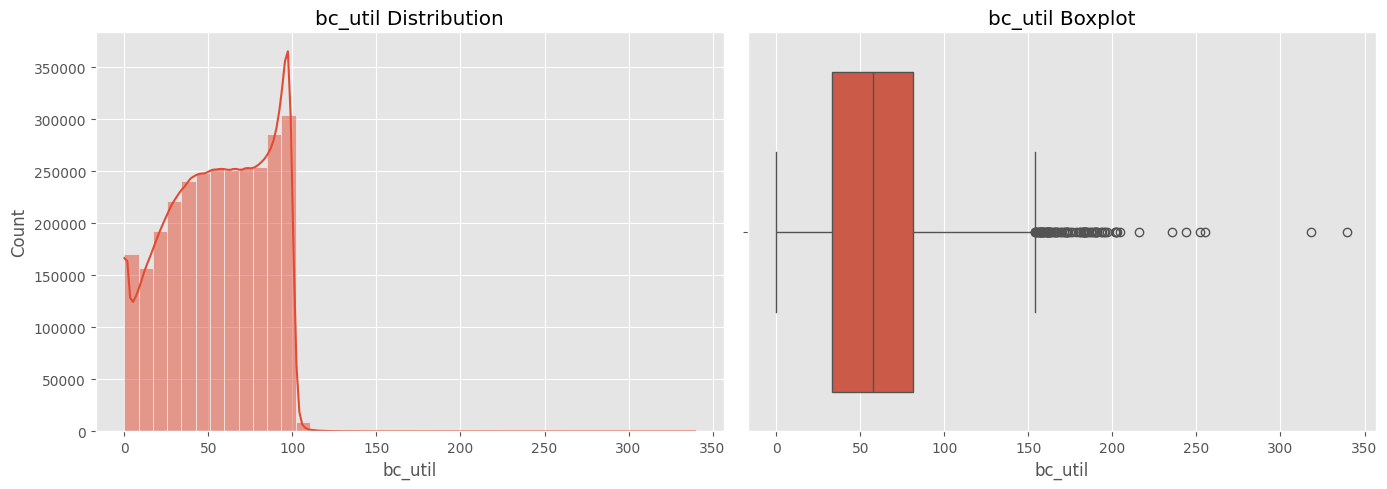

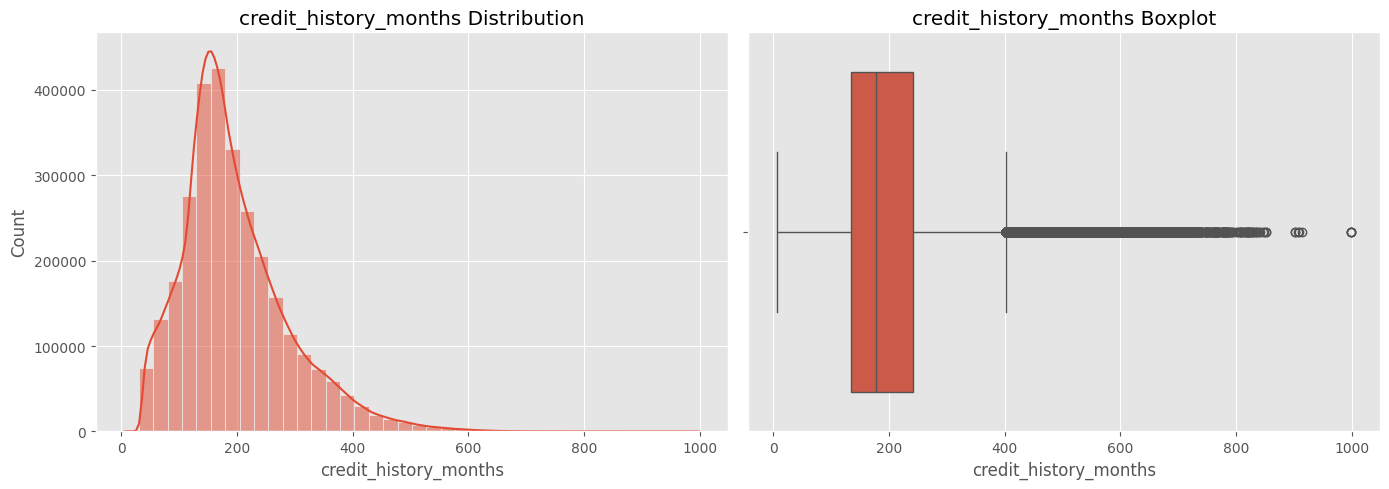

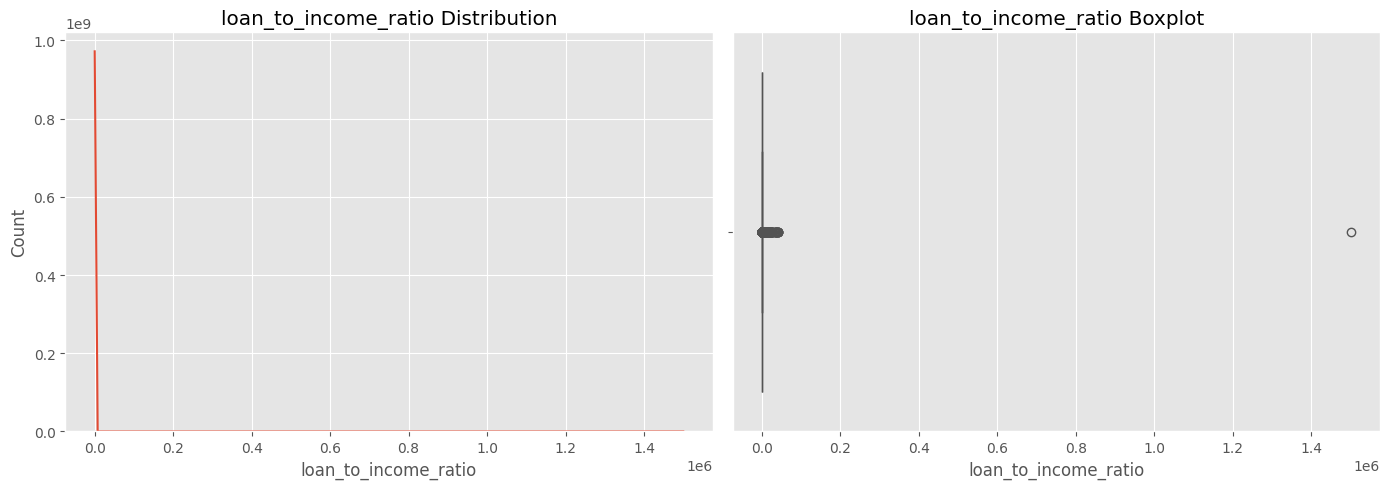

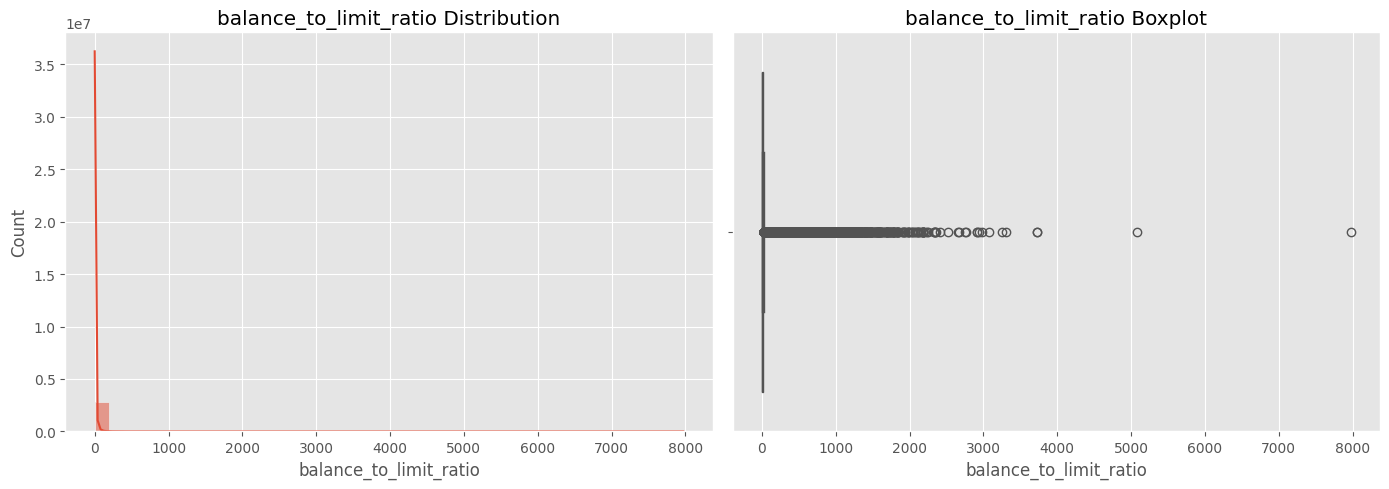

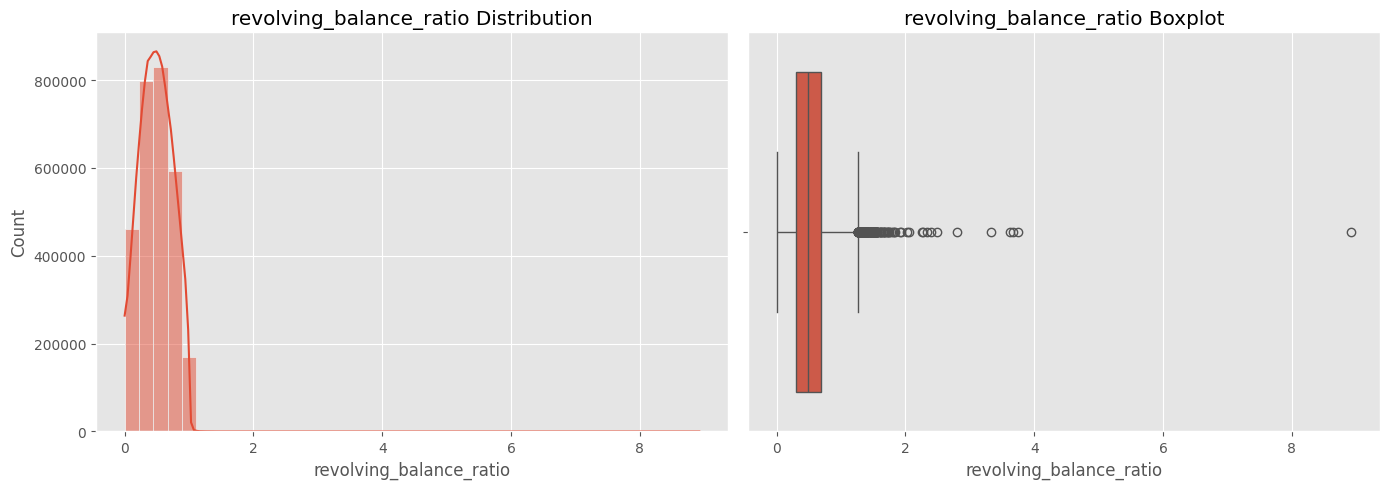

In [36]:
for feature in key_numeric_features:

    plot_distribution(df, feature)

## What to Observe

For every variable, ask:

## Distribution Shape
- Is it normally distributed?
- Is it right-skewed?
- Is it left-skewed?
- Is it bimodal?

## Spread
- Is there high variability?
- Are most observations concentrated in a narrow range?

## Outliers
- Are extreme observations expected?
- Could they indicate data quality issues?

## Missing Values

Does the histogram reveal gaps caused by missing values?

## 6.3 Compare Distributions by Default Status

This is much more informative than looking at the overall distribution.

In [37]:
def compare_distribution(df, feature):

    plt.figure(figsize=(10,5))

    sns.kdeplot(
        data=df,
        x=feature,
        hue="default_flag",
        common_norm=False
    )

    plt.title(f"{feature} by Default Status")

    plt.show()

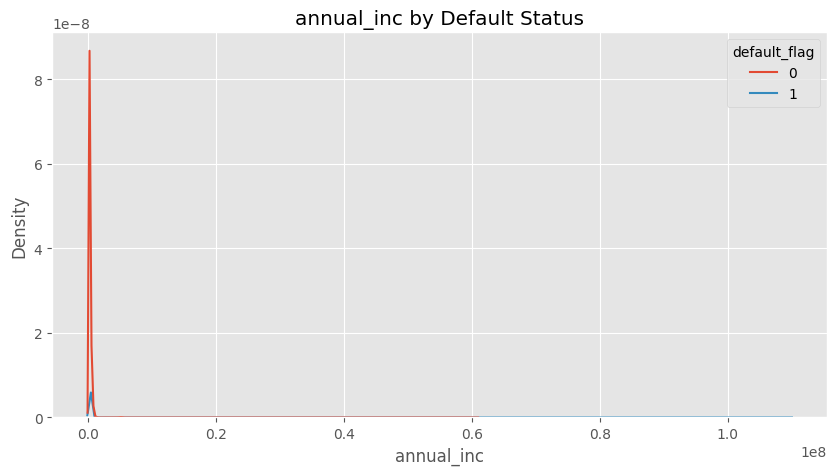

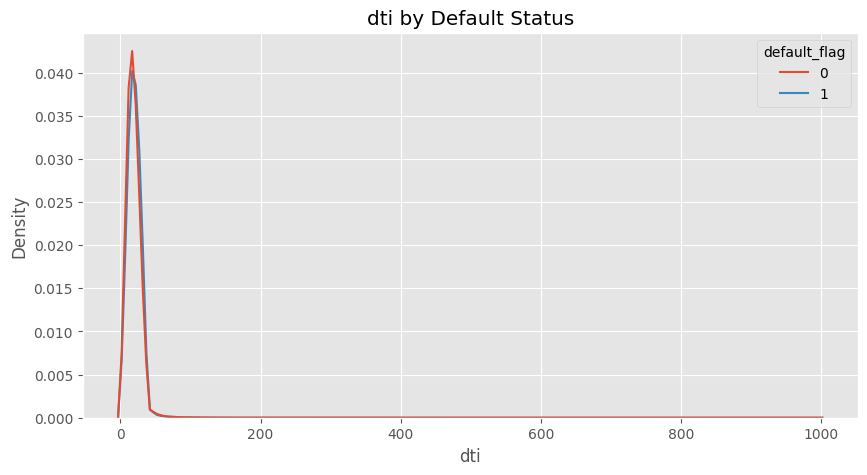

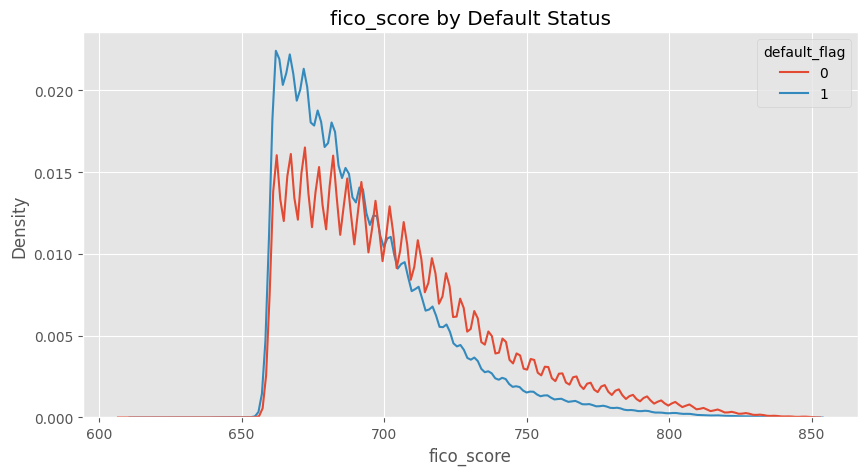

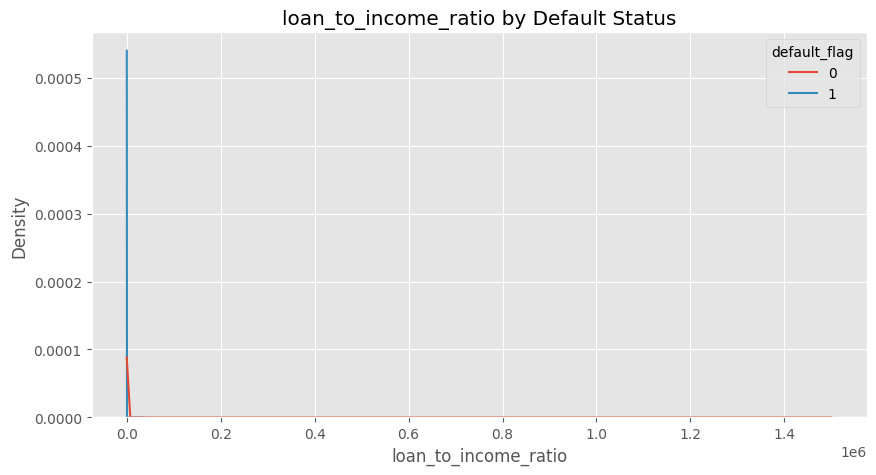

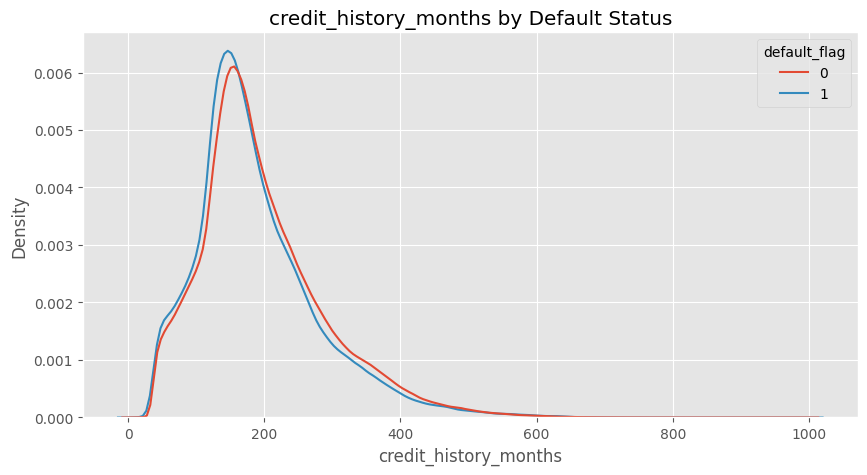

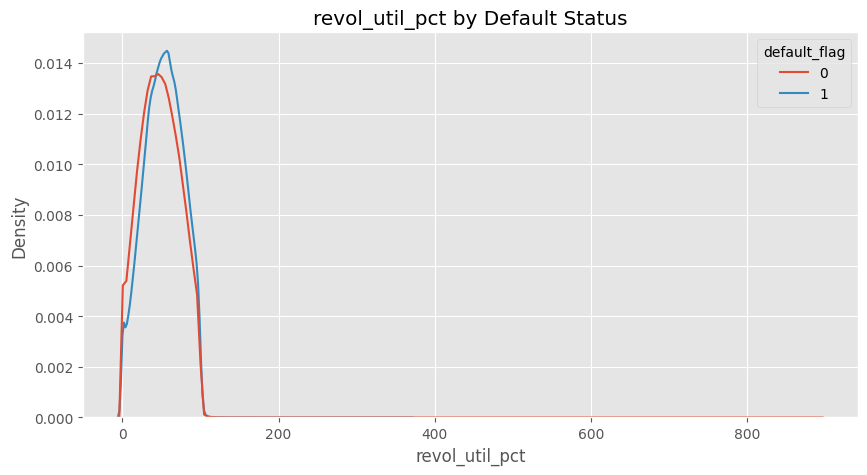

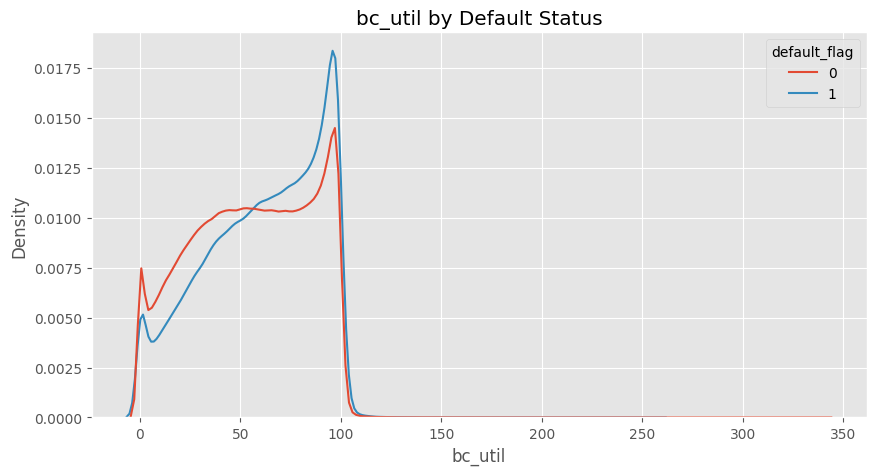

In [38]:
important_features = [

    "annual_inc",

    "dti",

    "fico_score",

    "loan_to_income_ratio",

    "credit_history_months",

    "revol_util_pct",

    "bc_util"

]

for feature in important_features:

    compare_distribution(df, feature)

These plots help determine whether a feature has discriminatory power.

For example:

- Defaulted borrowers may have lower FICO scores.
- Defaulted borrowers may have higher DTI ratios.
- Defaulted borrowers may have shorter credit histories.

The greater the separation between the two distributions, the more predictive the feature is likely to be.

## 6.4 Correlation with the Target

Compute the Pearson correlation between each numerical feature and the default indicator.

In [39]:
target_corr = (
    df[numeric_features]
    .corrwith(df["default_flag"])
    .sort_values()
)

target_corr

last_fico_score             -0.603146
fico_change                 -0.593445
fico_score                  -0.120635
total_bc_limit              -0.080801
total_rev_hi_lim            -0.063640
tot_cur_bal                 -0.058121
mortgage_flag               -0.043196
mort_acc                    -0.041844
credit_history_months       -0.032174
revol_bal                   -0.027704
annual_inc                  -0.026371
employment_stability_flag   -0.010832
high_dti_flag               -0.007540
emp_length_years            -0.005415
thin_file_flag              -0.000288
funded_to_income_ratio      -0.000226
loan_to_income_ratio        -0.000226
installment_income_ratio    -0.000220
total_acc                    0.003934
subprime_flag                0.006883
balance_to_limit_ratio       0.008289
acc_now_delinq               0.008754
open_acc                     0.010572
delinq_2yrs                  0.020871
delinquency_flag             0.022146
funded_amnt_inv              0.023181
funded_amnt 

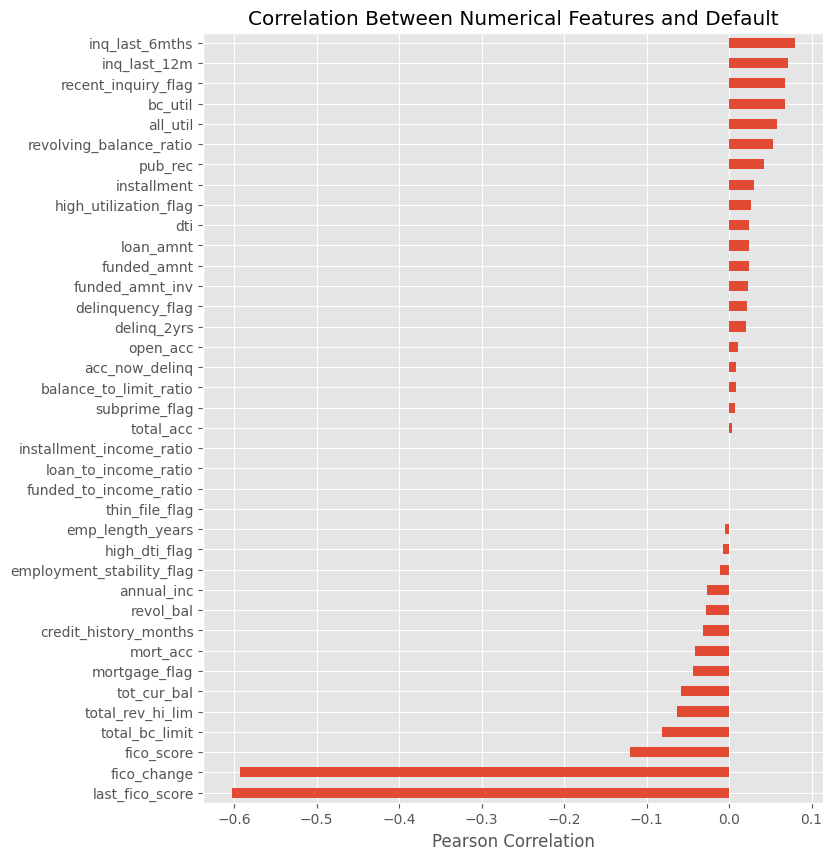

In [40]:
# Visualize the results.

plt.figure(figsize=(8,10))

target_corr.plot(kind="barh")

plt.title("Correlation Between Numerical Features and Default")

plt.xlabel("Pearson Correlation")

plt.show()

Although logistic regression and WoE modelling do not rely solely on linear relationships, Pearson correlation provides a useful initial indication of association.

Variables with larger absolute correlations deserve closer examination during feature selection, while weak correlations do not necessarily imply a lack of predictive value—many credit risk relationships are non-linear and will be better captured through WoE binning.

The numerical feature analysis shows that several financial variables, including annual income, revolving balances, and credit limits, are highly right-skewed, reflecting the natural distribution of financial data. FICO scores and debt-to-income ratios appear to provide clear separation between defaulted and non-defaulted borrowers, suggesting they are likely to be strong predictors of credit risk. While some variables exhibit extreme observations, these values are consistent with genuine borrower characteristics rather than obvious data quality issues and will therefore be retained pending further evaluation. Subsequent preprocessing will assess whether logarithmic transformations or winsorization improve model stability before WoE binning and model training.

# 7. Categorical Feature Analysis

The objective of this EDA is to understand each categorical feature before deciding whether categories should be merged, whether rare categories exist, and whether the feature is likely to be predictive of default.

Categorical variables describe borrower characteristics that cannot be measured on a continuous scale. Examples include:

- Credit grade
- Loan purpose
- Home ownership
- Application type

Unlike numerical variables, categorical variables are analysed by examining:

- category frequencies,
- default rates,
- category distributions,
- rare levels,
- and their relationship with the target variable.

These analyses provide the foundation for subsequent Weight of Evidence (WoE) encoding and Information Value (IV) calculations.

## 7.1 Identify Categorical Variables

First, identify all categorical features.

In [41]:
categorical_features = (
    df.select_dtypes(include=["object", "category"])
      .columns
      .tolist()
)

# Remove identifier
categorical_features.remove("id")

categorical_features

['int_rate_pct',
 'grade',
 'sub_grade',
 'purpose',
 'application_type',
 'home_ownership',
 'revol_util_pct',
 'fico_band']

Separating categorical variables allows us to automate frequency analysis and later apply WoE encoding.

## 7.2 Dataset Overview



In [42]:
# Display the number of unique categories.

categorical_summary = pd.DataFrame({
    "Unique Categories": df[categorical_features].nunique(),
    "Missing Values": df[categorical_features].isna().sum()
})

categorical_summary.sort_values(
    "Unique Categories",
    ascending=False
)

,Unique Categories,Missing Values
revol_util_pct,1443,2660
int_rate_pct,704,0
sub_grade,35,0
purpose,14,0
grade,7,0
home_ownership,6,0
fico_band,4,0
application_type,2,0


Variables with very large numbers of categories may require grouping before WoE encoding.

Fortunately, Lending Club variables are already fairly compact.

## 7.3 Frequency Distribution

In [43]:
# Create a reusable function.

def plot_category_distribution(df, feature):

    counts = (
        df[feature]
        .value_counts(dropna=False)
        .reset_index()
    )

    counts.columns = [feature, "Count"]

    plt.figure(figsize=(10,5))

    sns.barplot(
        data=counts,
        x=feature,
        y="Count"
    )

    plt.title(f"Distribution of {feature}")

    plt.xticks(rotation=45)

    plt.show()

In [44]:
# for feature in categorical_features:

  #  plot_category_distribution(df, feature)

In [45]:
# Frequency Tables

for feature in categorical_features:

    print("="*60)
    print(feature)

    display(
        df[feature]
        .value_counts(dropna=False)
        .to_frame("Count")
    )

int_rate_pct


,Count
int_rate_pct,
8.190000000,68199
11.990000000,53861
8.810000000,47392
5.320000000,47171
6.460000000,46169
...,...
17.410000000,1
13.190000000,1
17.440000000,1


grade


,Count
grade,
B,857573
C,802280
A,656302
D,416280
E,139036
F,41836
G,12185


sub_grade


...

,Count
home_ownership,
MORTGAGE,1437859
RENT,1152596
OWN,331281
ANY,3519
OTHER,182
NONE,55


revol_util_pct


,Count
revol_util_pct,
0E-9,18856
48.000000000,5247
57.000000000,5203
53.000000000,5147
49.000000000,5100
...,...
130.800000000,1
2.640000000,1
122.500000000,1


fico_band


,Count
fico_band,
Good,2077002
Fair,441617
Very Good,362968
Exceptional,43905


Counts can be misleading on very large datasets.

Instead compute percentages.

In [46]:
for feature in categorical_features:

    print("="*60)
    print(feature)

    display(
        (
            df[feature]
            .value_counts(normalize=True, dropna=False)
            .mul(100)
            .round(2)
            .to_frame("Percentage")
        )
    )

int_rate_pct


,Percentage
int_rate_pct,
8.190000000,2.33
11.990000000,1.84
8.810000000,1.62
5.320000000,1.61
6.460000000,1.58
...,...
17.410000000,0.00
13.190000000,0.00
17.440000000,0.00


grade


,Percentage
grade,
B,29.31
C,27.42
A,22.43
D,14.23
E,4.75
F,1.43
G,0.42


sub_grade


...

,Percentage
home_ownership,
MORTGAGE,49.15
RENT,39.40
OWN,11.32
ANY,0.12
OTHER,0.01
NONE,0.00


revol_util_pct


,Percentage
revol_util_pct,
0E-9,0.64
48.000000000,0.18
57.000000000,0.18
53.000000000,0.18
49.000000000,0.17
...,...
130.800000000,0.00
2.640000000,0.00
122.500000000,0.00


fico_band


,Percentage
fico_band,
Good,71.00
Fair,15.10
Very Good,12.41
Exceptional,1.50


This identifies categories representing less than 1% of the data.

These often become unstable during WoE estimation.

In [47]:
def rare_categories(df, feature, threshold=1):

    pct = (
        df[feature]
        .value_counts(normalize=True)
        * 100
    )

    return pct[pct < threshold]

In [48]:
for feature in categorical_features:

    rare = rare_categories(df, feature)

    if len(rare):

        print(f"\n{feature}")

        display(rare)


int_rate_pct


int_rate_pct
7.890000000     0.974674
9.170000000     0.951464
11.710000000    0.909488
15.610000000    0.861667
14.990000000    0.858146
                  ...   
17.410000000    0.000034
13.190000000    0.000034
17.440000000    0.000034
22.620000000    0.000034
16.830000000    0.000034
Name: proportion, Length: 688, dtype: float64


grade


grade
G    0.416511
Name: proportion, dtype: float64


sub_grade


...

purpose
vacation            0.690345
house               0.669836
moving              0.655753
wedding             0.080499
renewable_energy    0.060400
educational         0.014493
Name: proportion, dtype: float64


home_ownership


home_ownership
ANY      0.120287
OTHER    0.006221
NONE     0.001880
Name: proportion, dtype: float64


revol_util_pct


revol_util_pct
0E-9             0.645128
48.000000000     0.179518
57.000000000     0.178012
53.000000000     0.176096
49.000000000     0.174488
                   ...   
69.980000000     0.000034
134.100000000    0.000034
191.000000000    0.000034
27.810000000     0.000034
24.650000000     0.000034
Name: proportion, Length: 1443, dtype: float64

Rare categories often:

- produce unstable WoE values,
- inflate Information Value,
- increase overfitting.

Later they can be merged into an "Other" category if appropriate.

## 9.4 Target Rate by Category

In [49]:
def default_rate_by_category(df, feature):

    summary = (
        df.groupby(feature)
          .agg(
              observations=("default_flag", "size"),
              defaults=("default_flag", "sum"),
              default_rate=("default_flag", "mean")
          )
          .sort_values("default_rate", ascending=False)
    )

    summary["default_rate"] *= 100

    return summary.round(2)

In [50]:
for feature in categorical_features:

    print("="*60)
    print(feature)

    display(
        default_rate_by_category(df, feature)
    )

int_rate_pct


,observations,defaults,default_rate
int_rate_pct,,,
24.400000000,1,1,100.0
16.900000000,1,1,100.0
17.410000000,1,1,100.0
11.160000000,1,1,100.0
18.720000000,1,1,100.0
...,...,...,...
18.860000000,3,0,0.0
17.440000000,1,0,0.0
17.500000000,1,0,0.0


grade


,observations,defaults,default_rate
grade,,,
G,12185,5368,44.05
F,41836,16737,40.01
E,139036,44805,32.23
D,416280,86868,20.87
C,802280,123735,15.42
B,857573,78160,9.11
A,656302,24223,3.69


sub_grade


...

,observations,defaults,default_rate
home_ownership,,,
OTHER,182,38,20.88
RENT,1152596,174171,15.11
NONE,55,8,14.55
OWN,331281,43527,13.14
MORTGAGE,1437859,161862,11.26
ANY,3519,290,8.24


revol_util_pct


,observations,defaults,default_rate
revol_util_pct,,,
0.120000000,1,1,100.0
366.600000000,1,1,100.0
158.700000000,1,1,100.0
152.600000000,1,1,100.0
148.000000000,1,1,100.0
...,...,...,...
137.800000000,1,0,0.0
137.900000000,1,0,0.0
138.500000000,1,0,0.0


fico_band


,observations,defaults,default_rate
fico_band,,,
Fair,441617,82414,18.66
Good,2077002,272793,13.13
Very Good,362968,22799,6.28
Exceptional,43905,1890,4.3


If default rates increase consistently from Grade A to Grade G, the variable is almost certainly predictive and should perform well after WoE encoding.

In [51]:
def plot_default_rate(df, feature):

    summary = default_rate_by_category(df, feature)

    plt.figure(figsize=(10,5))

    sns.barplot(
        x=summary.index,
        y=summary["default_rate"]
    )

    plt.ylabel("Default Rate (%)")

    plt.title(f"Default Rate by {feature}")

    plt.xticks(rotation=45)

    plt.show()

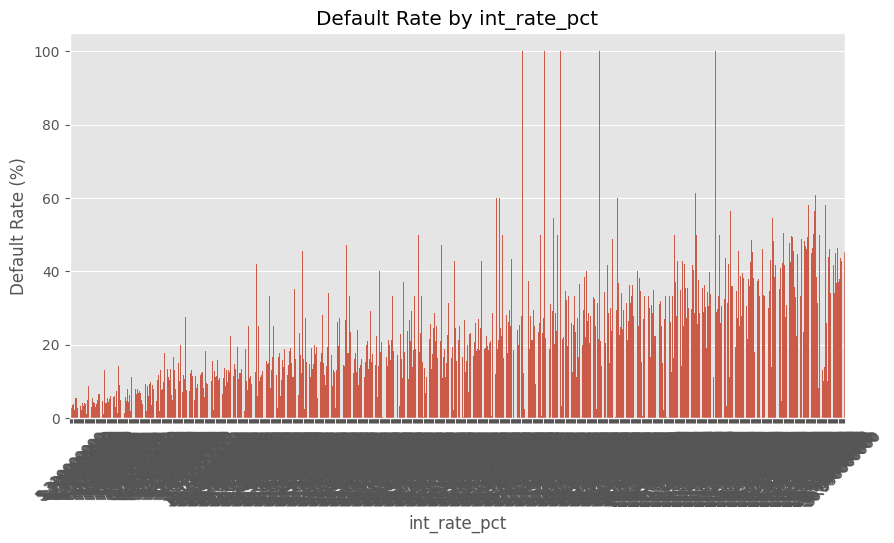

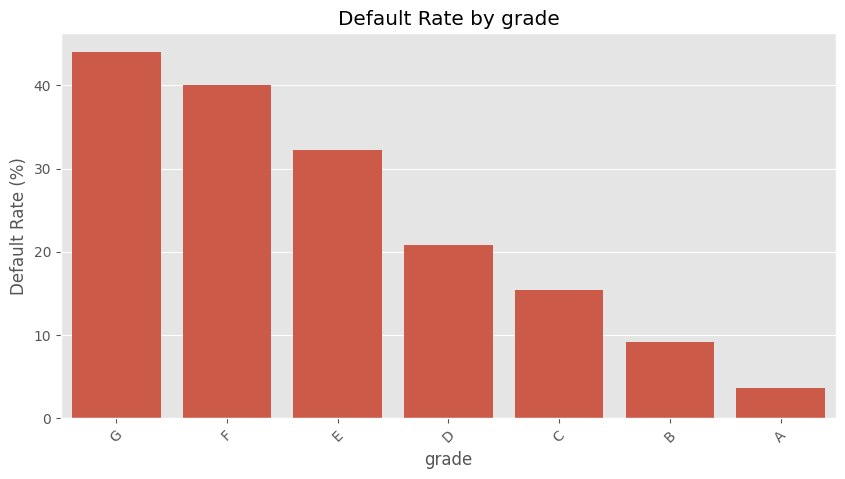

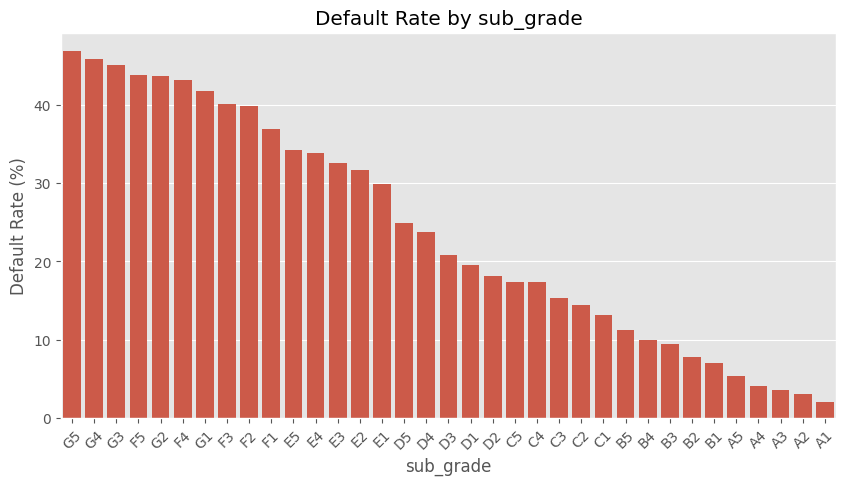

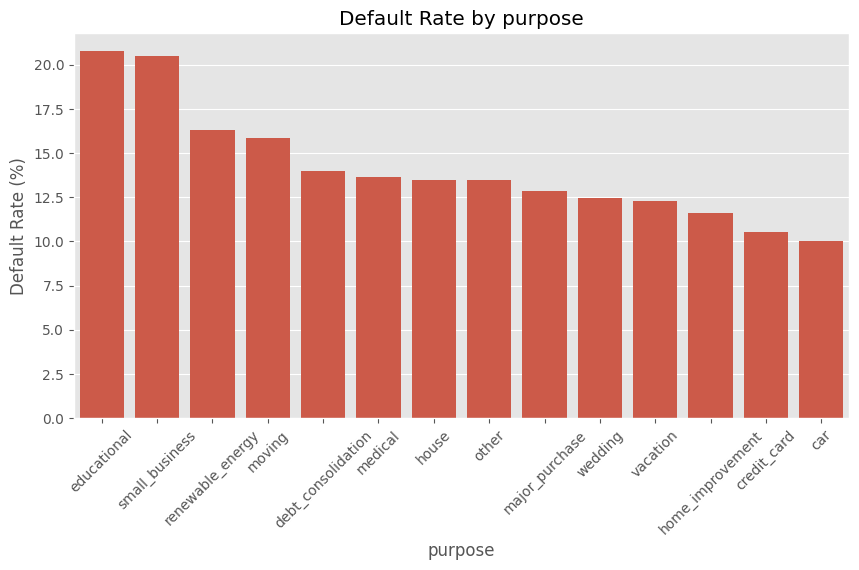

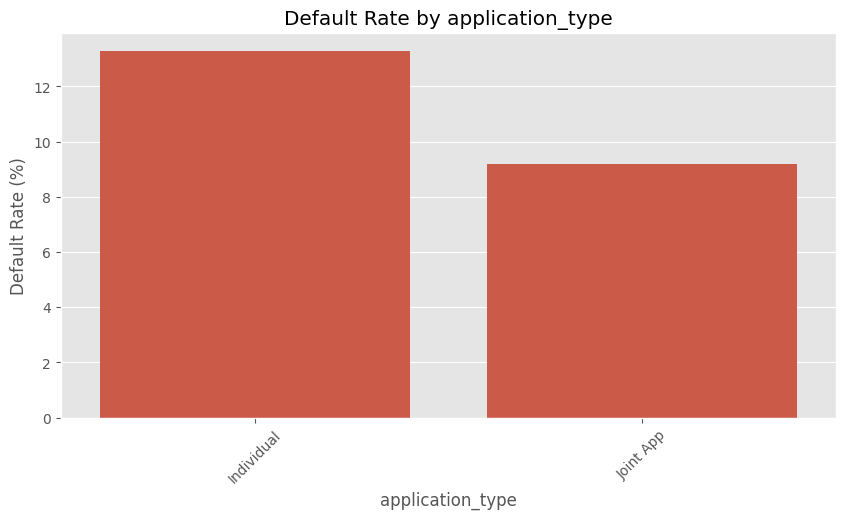

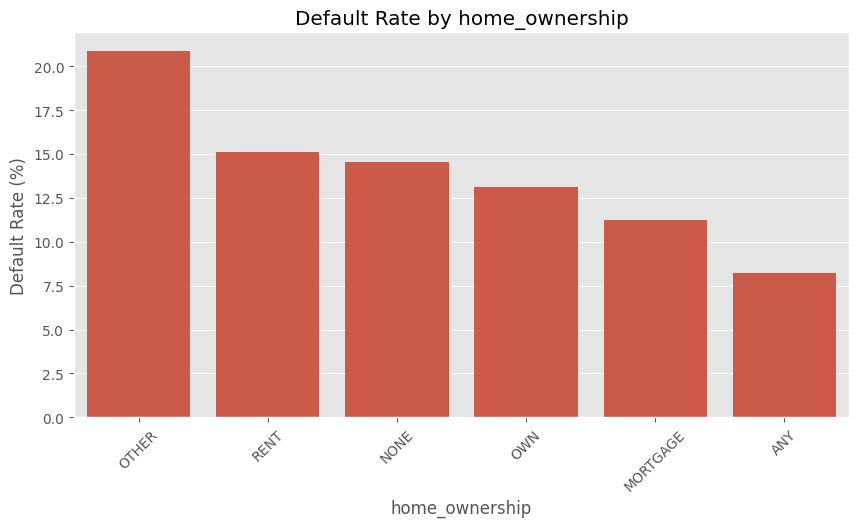

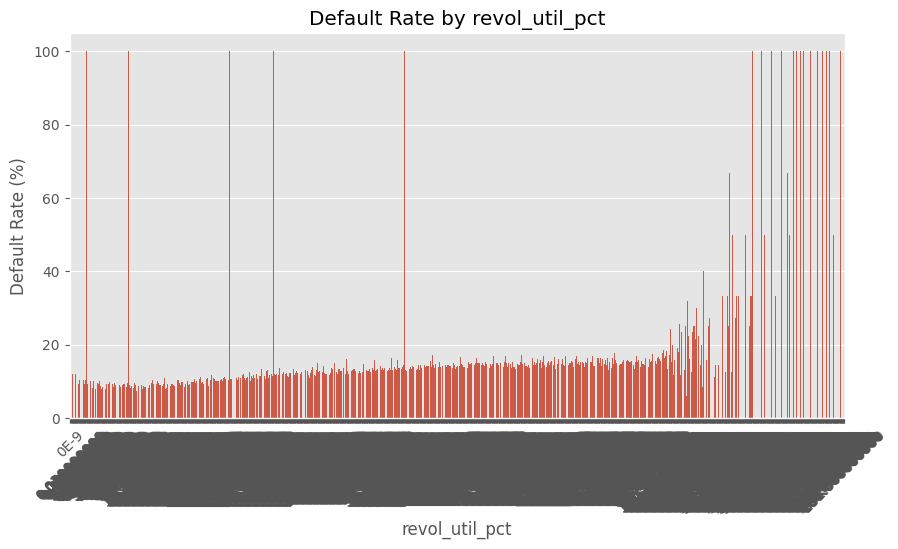

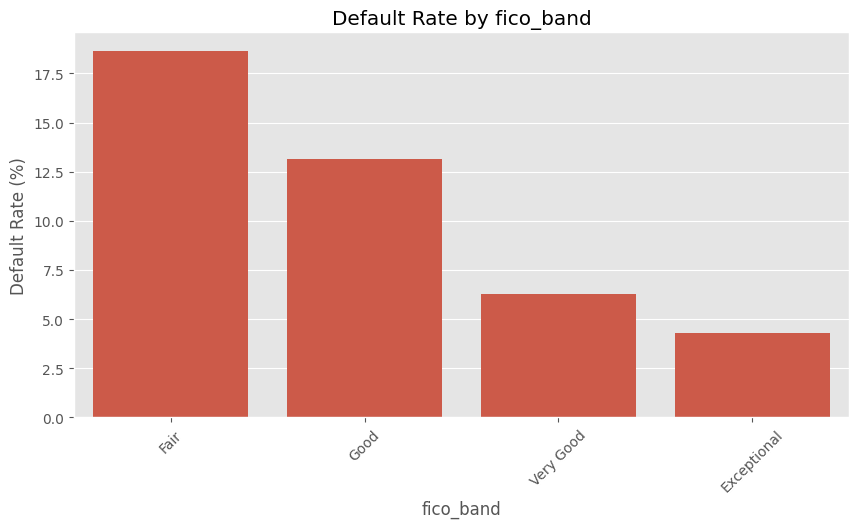

In [52]:
for feature in categorical_features:

    plot_default_rate(df, feature)

In [53]:
# Compare Categories by Target

for feature in categorical_features:

    print(feature)

    display(
        pd.crosstab(
            df[feature],
            df["default_flag"],
            normalize="index"
        ) * 100
    )

int_rate_pct


default_flag,0,1
int_rate_pct,,
5.310000000,97.794032,2.205968
5.320000000,97.129592,2.870408
5.420000000,96.509599,3.490401
5.790000000,96.097561,3.902439
5.930000000,97.792494,2.207506
...,...,...
30.790000000,62.103929,37.896071
30.840000000,56.413613,43.586387
30.890000000,57.142857,42.857143


grade


default_flag,0,1
grade,,
A,96.309169,3.690831
B,90.885907,9.114093
C,84.577080,15.422920
D,79.132315,20.867685
E,67.774533,32.225467
F,59.993785,40.006215
G,55.945835,44.054165


sub_grade


...

default_flag,0,1
home_ownership,,
ANY,91.759022,8.240978
MORTGAGE,88.742846,11.257154
NONE,85.454545,14.545455
OTHER,79.120879,20.879121
OWN,86.861003,13.138997
RENT,84.888808,15.111192


revol_util_pct


default_flag,0,1
revol_util_pct,,
0E-9,88.756894,11.243106
0.010000000,100.000000,0.000000
0.030000000,100.000000,0.000000
0.040000000,100.000000,0.000000
0.050000000,100.000000,0.000000
...,...,...
184.600000000,100.000000,0.000000
191.000000000,100.000000,0.000000
193.000000000,100.000000,0.000000


fico_band


default_flag,0,1
fico_band,,
Exceptional,95.695251,4.304749
Fair,81.338128,18.661872
Good,86.866021,13.133979
Very Good,93.718730,6.281270


This shows the percentage of defaults within each category, making differences between borrower groups easy to interpret.

The categorical feature analysis indicates that several application-level variables exhibit strong discriminatory power. In particular, grade, sub_grade, and fico_band demonstrate clear monotonic increases in default rates as credit quality declines, suggesting they will be highly informative after WoE encoding. Variables such as purpose and home_ownership show meaningful but less pronounced differences in default behaviour across categories. No significant missing values were observed among the categorical variables, although the preprocessing pipeline will include a dedicated missing-category imputer to ensure robustness when scoring future data. Rare categories identified during this analysis will be reviewed prior to WoE binning to determine whether they should be merged into an "Other" category, improving the stability of WoE estimates and reducing the risk of overfitting.

# 8. Pairwise Relationships

**Objective**

Individual feature distributions provide valuable information, but they do not reveal how variables interact with one another. Pairwise analysis helps identify relationships between predictors and assess whether those relationships differ between defaulted and non-defaulted borrowers.

This analysis helps us:

- identify correlated predictors,
- detect natural borrower clusters,
- understand feature interactions,
- validate engineered variables,
- identify variables that may separate defaulted and non-defaulted loans.

## 8.1 Select Important Features

Rather than plotting every variable, focus on the most predictive financial characteristics.

In [54]:
pairwise_features = [

    "fico_score",

    "annual_inc",

    "loan_amnt",

    "dti",

    "loan_to_income_ratio",

    "credit_history_months",

    "revol_util_pct",

    "default_flag"

]

In [55]:
# Because the dataset is large, use a random sample.

pair_sample = (
    df[pairwise_features]
    .sample(
        n=5000,
        random_state=42
    )
)

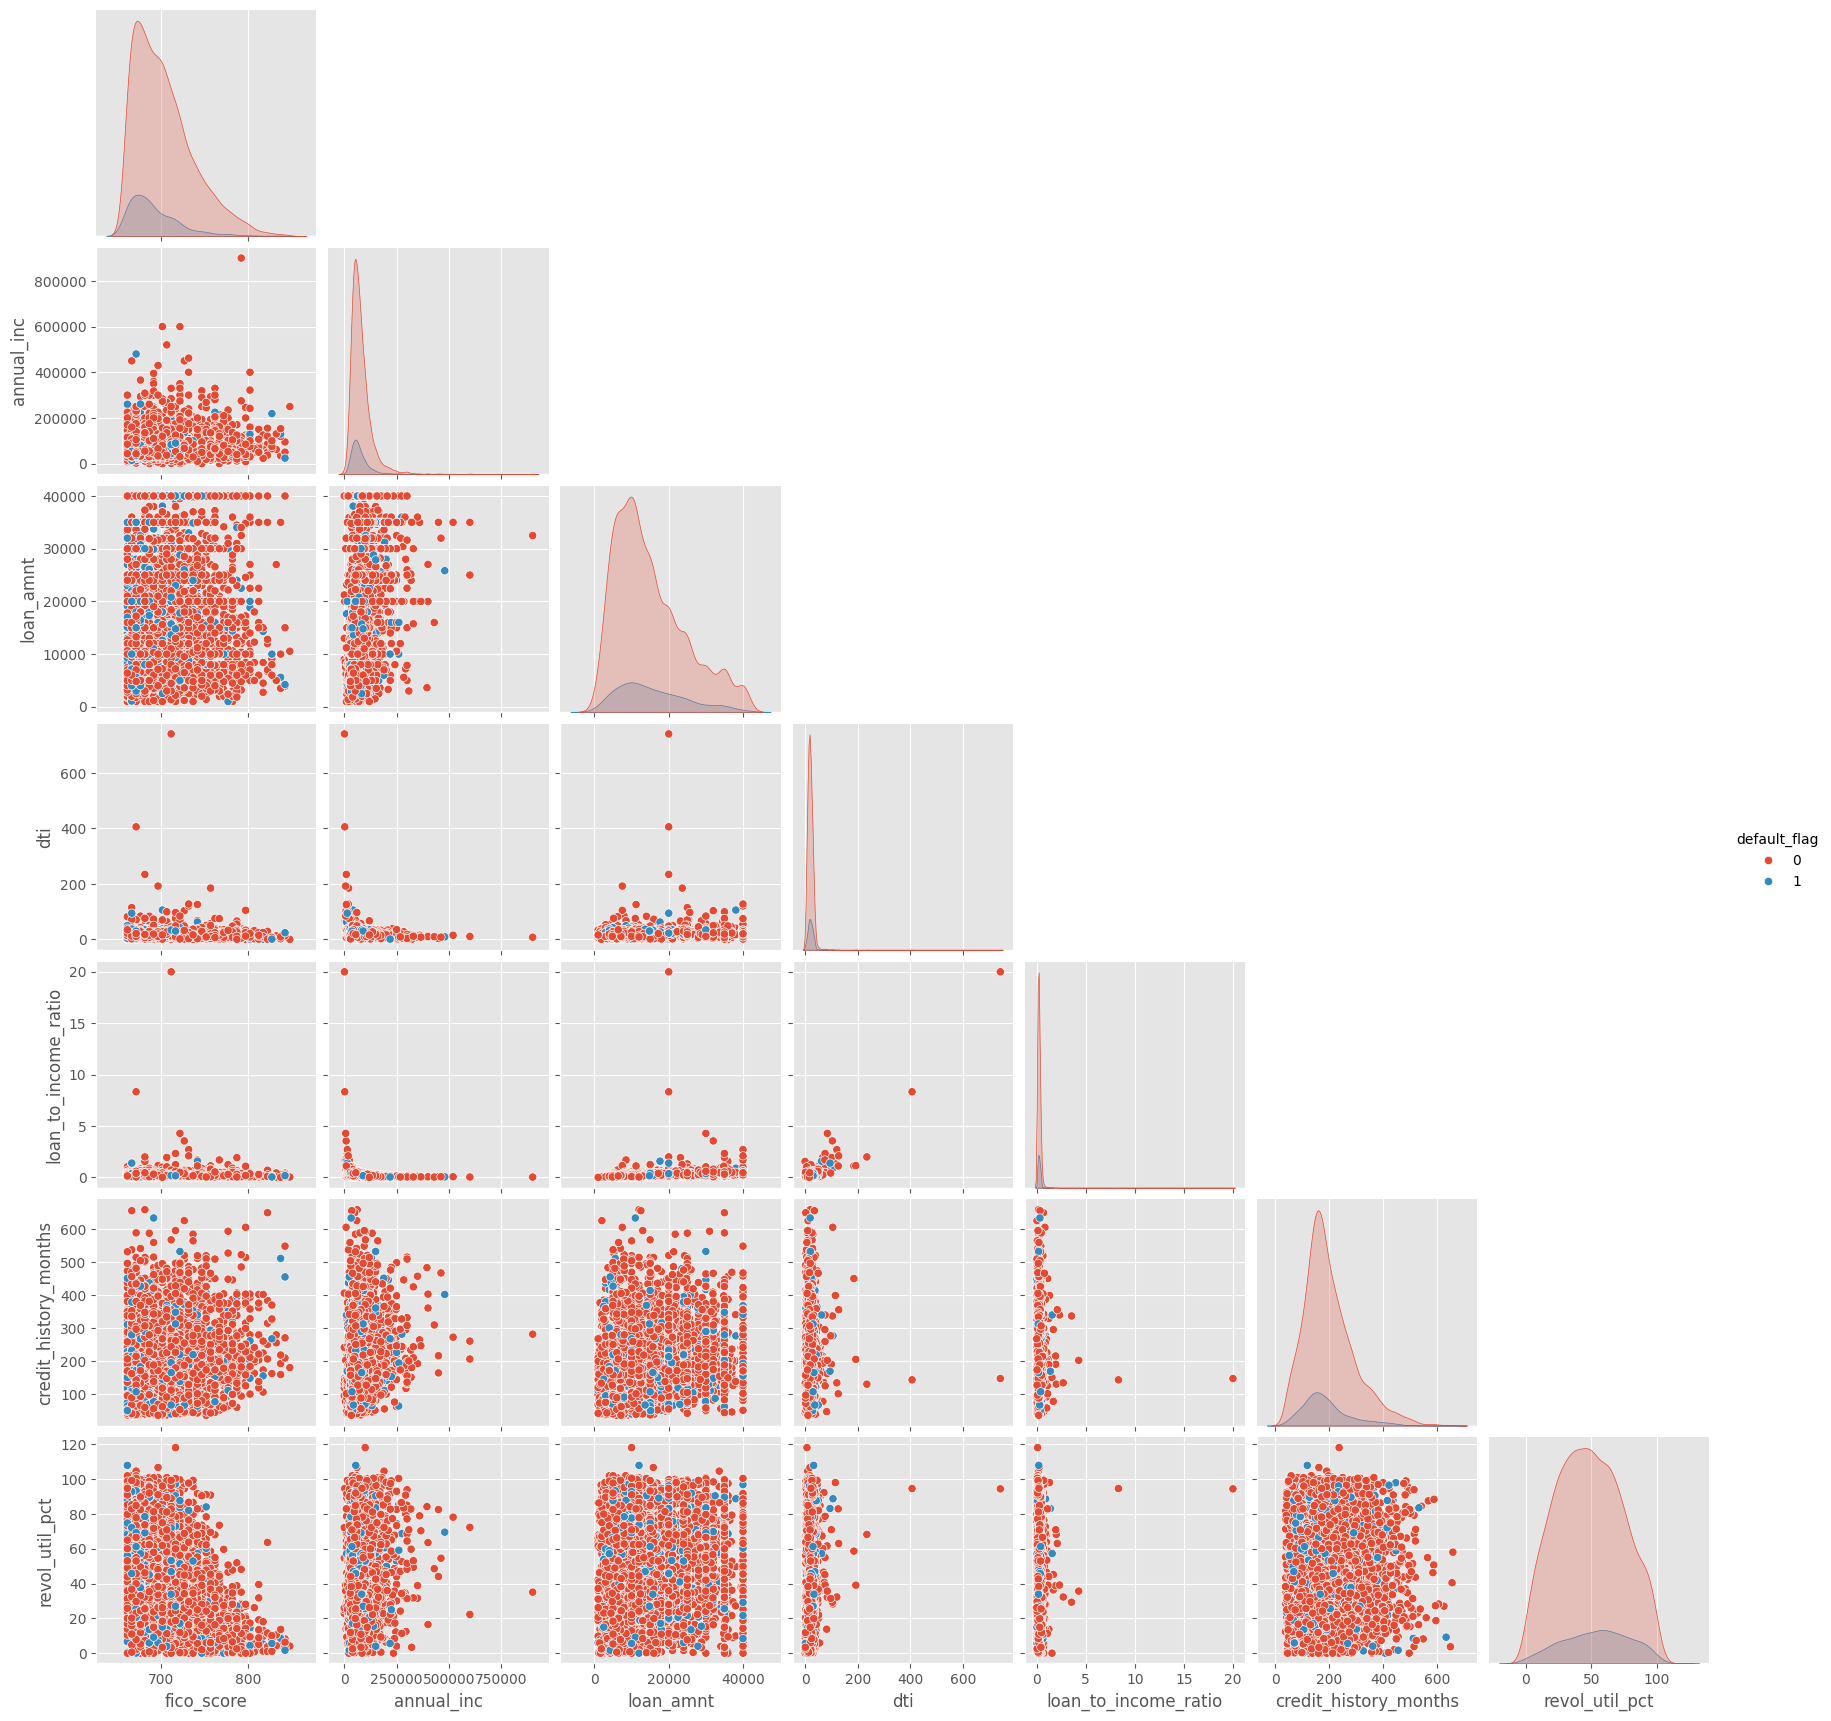

In [56]:
sns.pairplot(
    pair_sample,
    hue="default_flag",
    corner=True,
    diag_kind="kde"
)

plt.show()

The pairplot helps identify:

- linear relationships,
- non-linear relationships,
- natural borrower clusters,
- variables that separate defaults.

For example:

- Lower FICO scores cluster with higher DTI.
- Larger loan-to-income ratios correspond to higher default rates.

In [57]:
# Correlation Heatmap

corr = (
    df[
        pairwise_features[:-1]
    ]
    .corr()
)

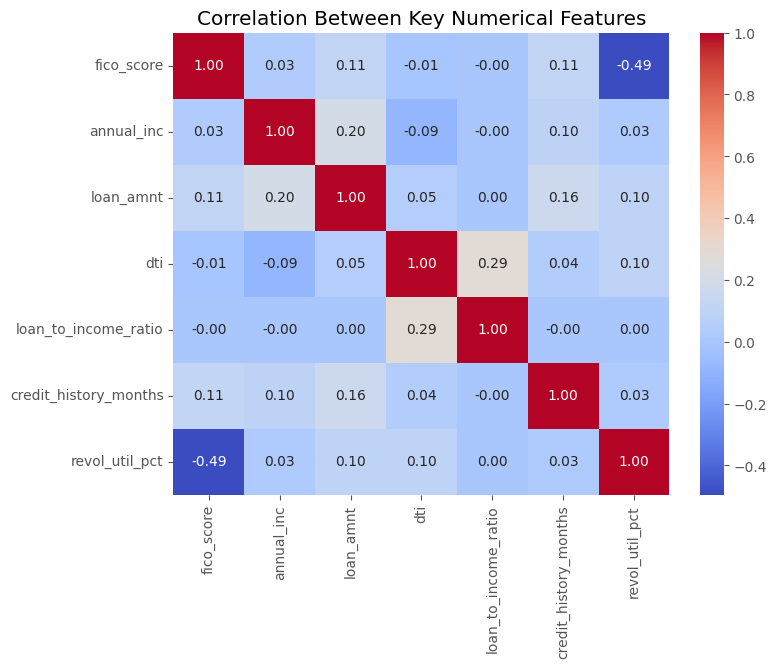

In [58]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Key Numerical Features")

plt.show()

We're looking for:

- very strong correlations (>0.80),
- duplicate information,
- multicollinearity before Logistic Regression.

# 9. Feature Engineering Validation

**Objective**

The intermediate dataset contains several engineered variables created during the dbt transformation layer.

Before using them for modelling, we must verify:

- they were calculated correctly,
- their values are reasonable,
- no impossible values exist,
- the distributions make business sense.

In [59]:
engineered_features = [

    "credit_history_months",

    "loan_to_income_ratio",

    "funded_to_income_ratio",

    "installment_income_ratio",

    "fico_change",

    "revolving_balance_ratio",

    "balance_to_limit_ratio"

]

In [60]:
# Summary statistics for engineered features

df[engineered_features].describe().T

,count,mean,std,min,25%,50%,75%,max
credit_history_months,2925463.0,196.259969,92.705829,6.0,135.0,178.0,242.0,999.0
loan_to_income_ratio,2922434.0,1.163566,883.405315,0.000161,0.123853,0.2,0.299319,1500000.0
funded_to_income_ratio,2922434.0,1.163508,883.405315,0.000161,0.12381,0.2,0.299145,1500000.0
installment_income_ratio,2922434.0,0.035983,29.45269,0.000005,0.003759,0.005895,0.008736,50109.0
fico_change,2925492.0,-18.401648,85.512375,-822.0,-45.0,0.0,30.0,185.5
revolving_balance_ratio,2853128.0,0.49301,0.248747,0.0,0.30097,0.489077,0.684362,8.923333
balance_to_limit_ratio,2822368.0,11.846254,34.862069,0.0,1.708377,4.61898,11.45106,7972.176667


## 9.1 Impossible Values

Credit risk variables should satisfy business rules.

In [61]:
validation = pd.DataFrame({
    "Negative Values": (df[engineered_features] < 0).sum(),
    "Missing Values": df[engineered_features].isna().sum()
})

validation

,Negative Values,Missing Values
credit_history_months,0,29
loan_to_income_ratio,0,3058
funded_to_income_ratio,0,3058
installment_income_ratio,0,3058
fico_change,1410964,0
revolving_balance_ratio,0,72364
balance_to_limit_ratio,0,103124


In [62]:
print("Negative credit history:",
      (df.credit_history_months < 0).sum())

print("Negative income ratios:",
      (df.loan_to_income_ratio < 0).sum())

print("Negative balance ratios:",
      (df.balance_to_limit_ratio < 0).sum())

Negative credit history: 0
Negative income ratios: 0
Negative balance ratios: 0


Negative values may indicate:

- calculation errors,
- incorrect joins,
- invalid source records.

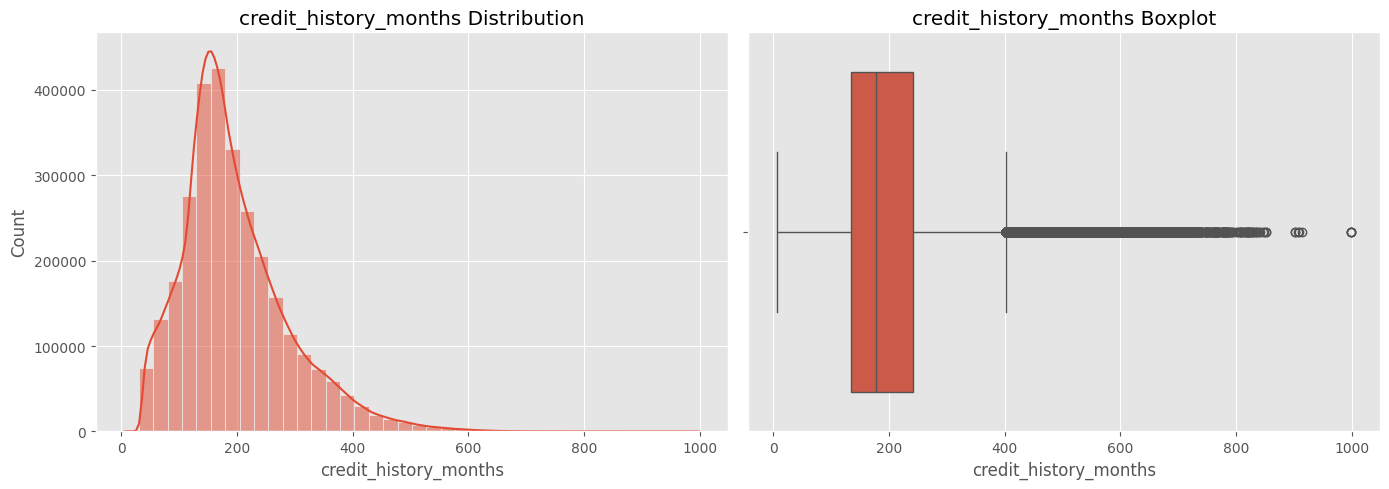

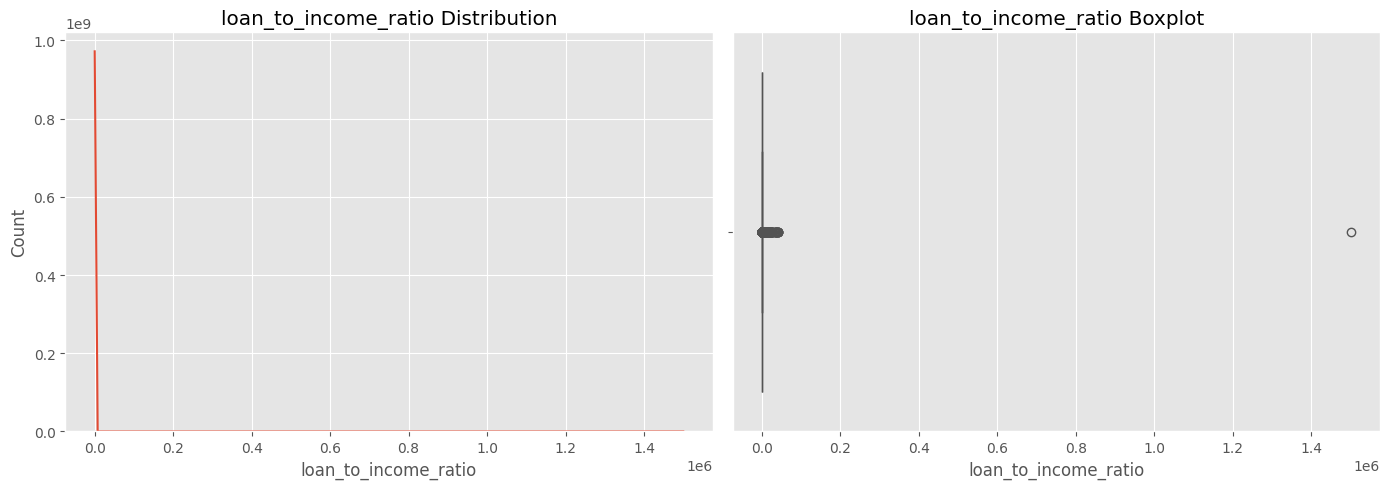

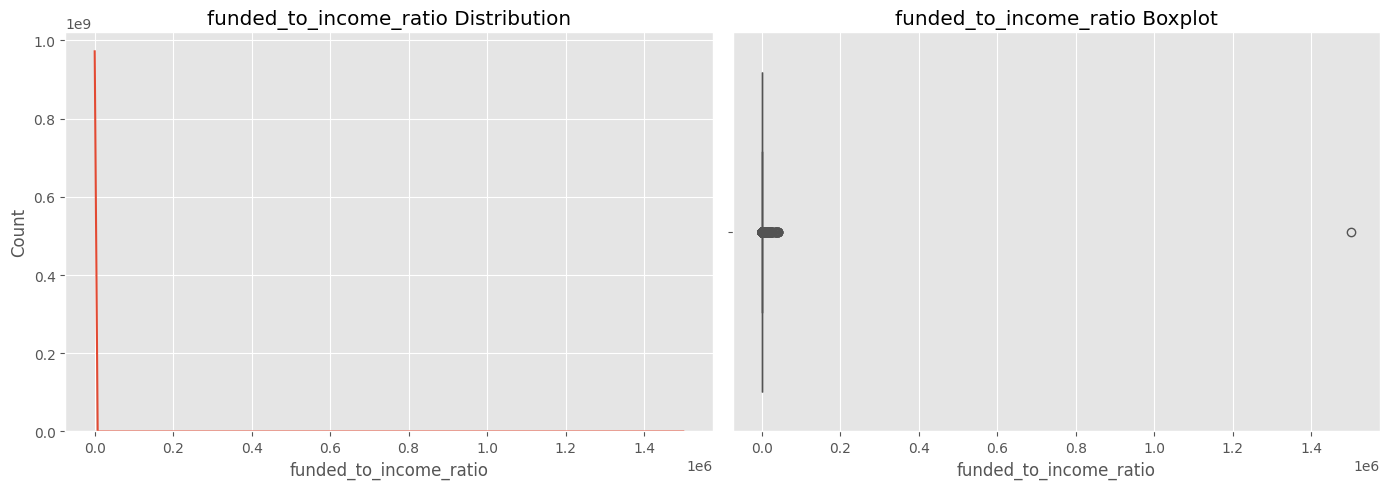

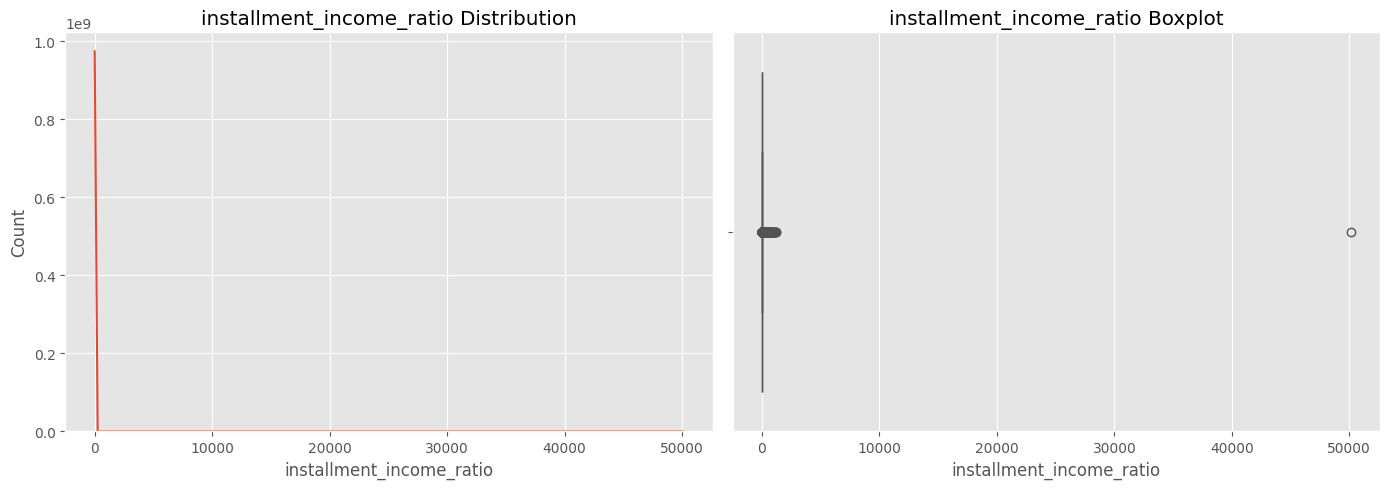

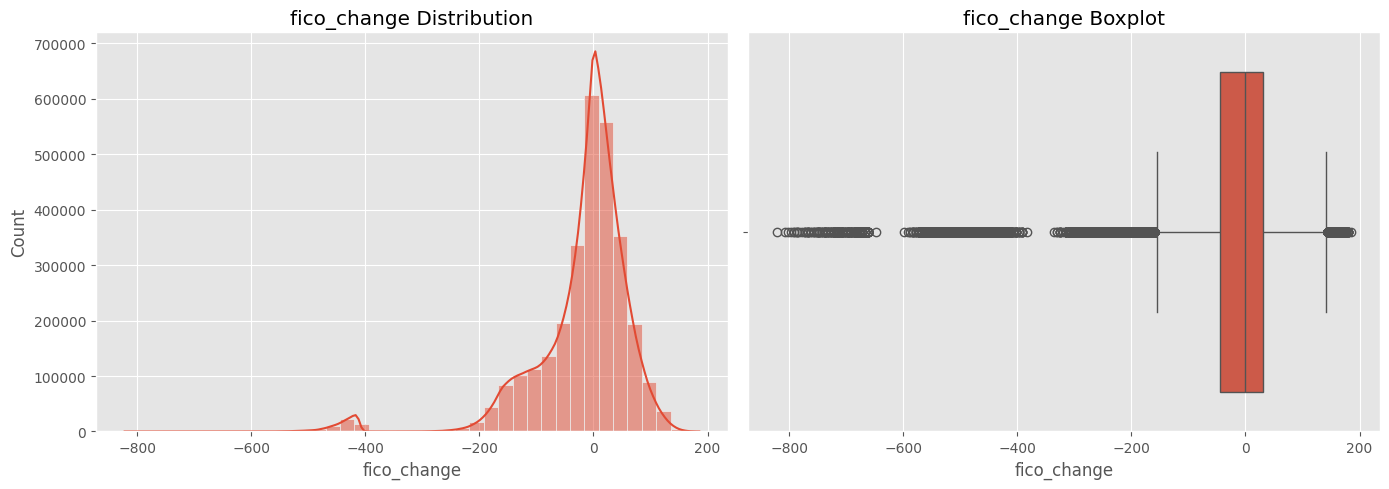

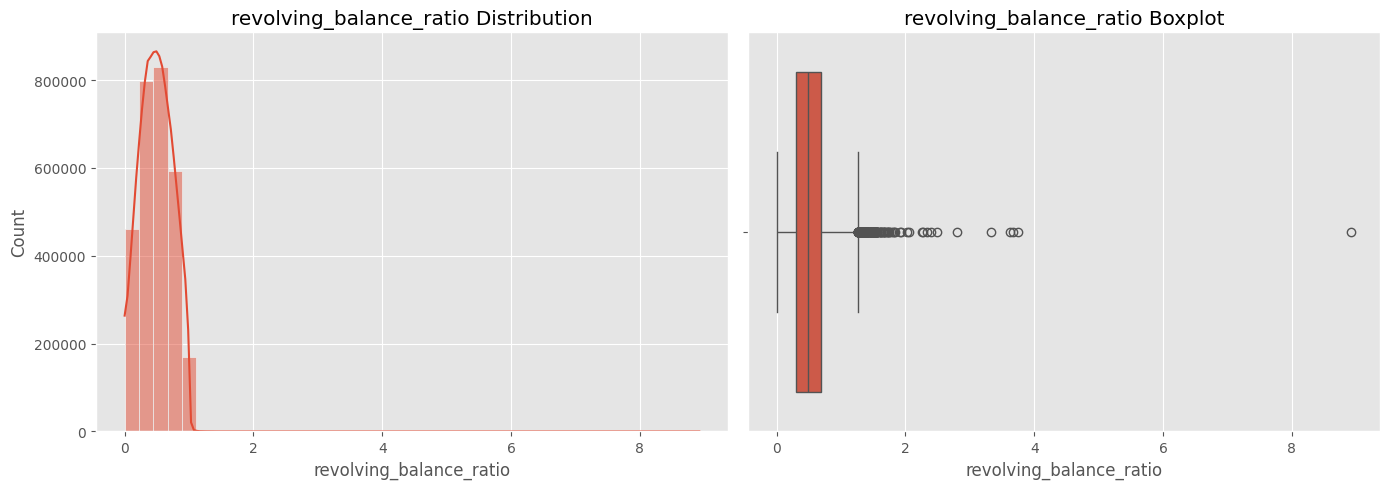

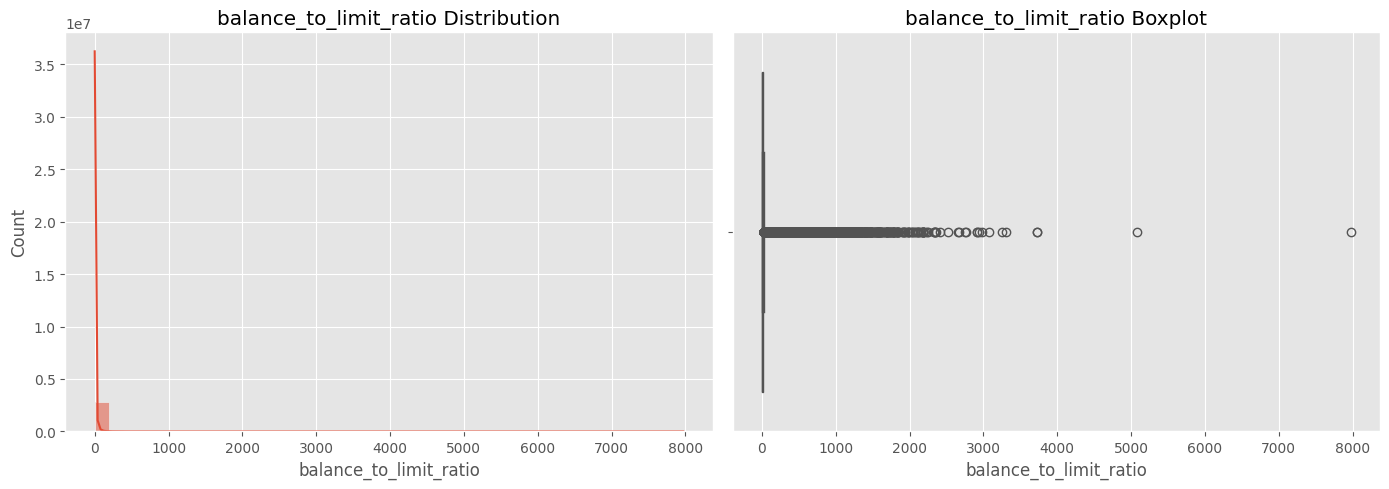

In [63]:
for feature in engineered_features:

    plot_distribution(df, feature)

- Are distributions reasonable?
- Extremely skewed?
- Impossible values?
- Candidate for Winsorization?

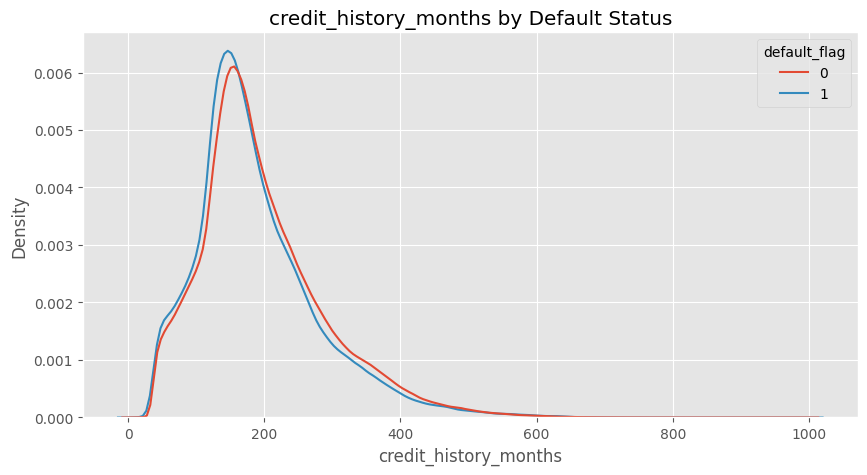

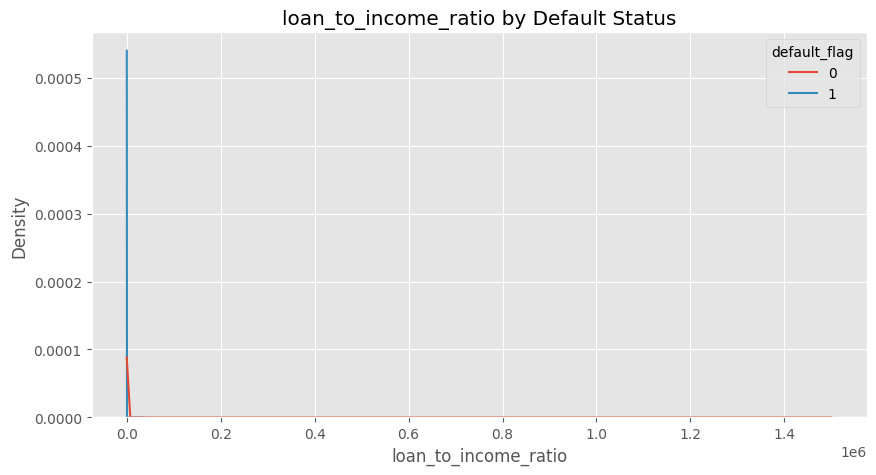

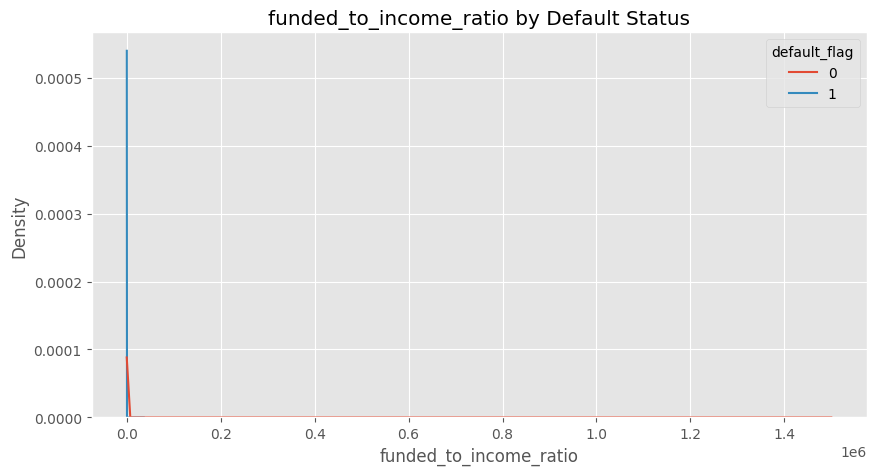

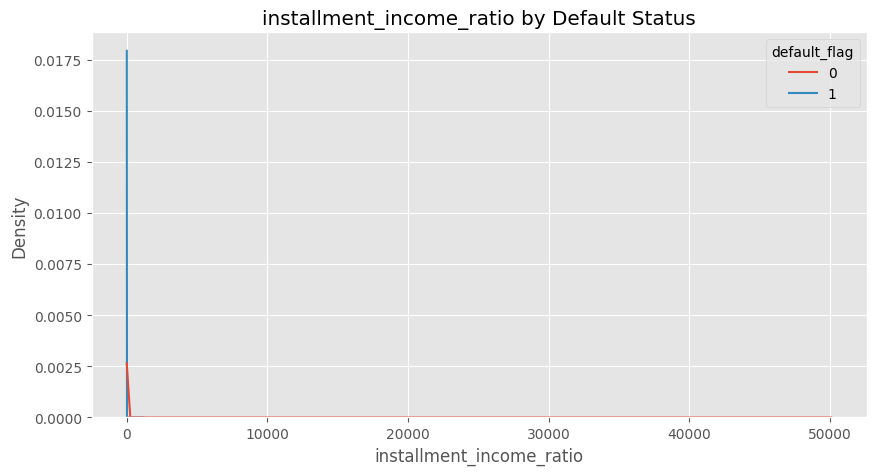

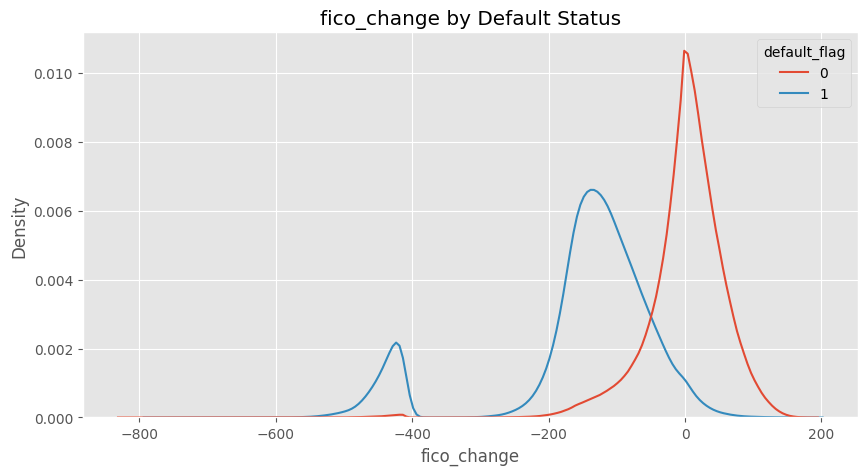

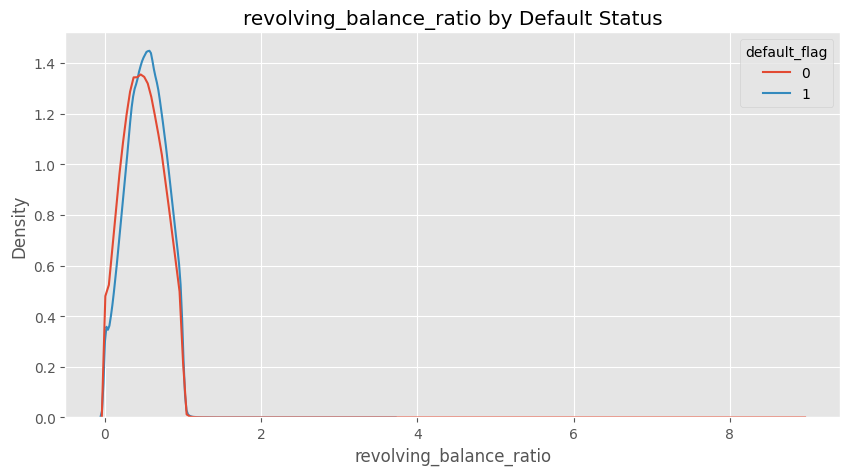

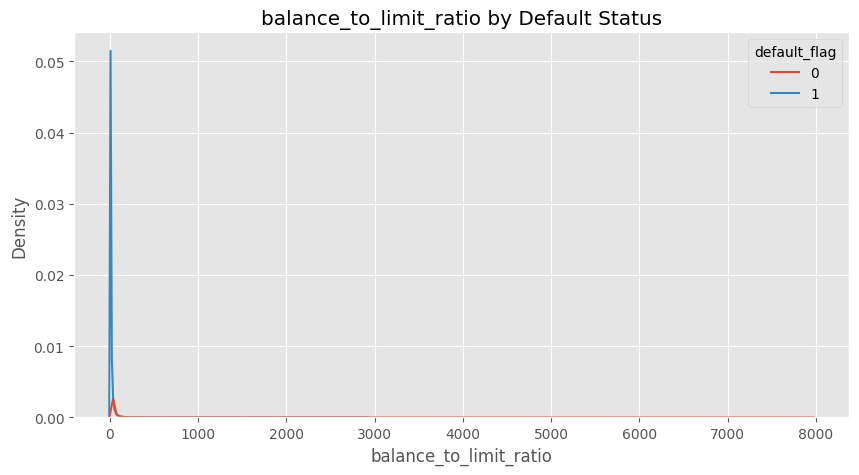

In [64]:
# Relationship with Default

for feature in engineered_features:

    compare_distribution(
        df,
        feature
    )

This helps determine whether the engineered variables contain useful predictive information.

## 9.2 Check Engineered Flags

**Objective**

Several binary indicators were engineered during feature engineering.

These should:

- contain only 0 and 1,
- represent meaningful borrower segments,
- exhibit different default rates.

In [65]:
flag_features = [

    "delinquency_flag",

    "recent_inquiry_flag",

    "high_utilization_flag",

    "thin_file_flag",

    "mortgage_flag",

    "employment_stability_flag",

    "high_dti_flag",

    "subprime_flag"

]

In [66]:
# Verify Binary Encoding

for feature in flag_features:

    print(feature)

    print(
        df[feature]
        .value_counts(dropna=False)
    )

    print("-"*40)

delinquency_flag
delinquency_flag
0    2406994
1     518498
Name: count, dtype: Int64
----------------------------------------
recent_inquiry_flag
recent_inquiry_flag
0    1813491
1    1112001
Name: count, dtype: Int64
----------------------------------------
high_utilization_flag
high_utilization_flag
0    2551155
1     374337
Name: count, dtype: Int64
----------------------------------------
thin_file_flag
thin_file_flag
0    2903155
1      22337
Name: count, dtype: Int64
----------------------------------------
mortgage_flag
mortgage_flag
1    1642250
0    1283242
Name: count, dtype: Int64
----------------------------------------
employment_stability_flag
employment_stability_flag
1    1583585
0    1341907
Name: count, dtype: Int64
----------------------------------------
high_dti_flag
high_dti_flag
0    2877169
1      48323
Name: count, dtype: Int64
----------------------------------------
subprime_flag
subprime_flag
0    2925003
1        489
Name: count, dtype: Int64
-------------

In [67]:
# Default Rate by Flag

def flag_summary(df, feature):

    return (
        df.groupby(feature)
          .agg(
              observations=("default_flag","size"),
              default_rate=("default_flag","mean")
          )
          .round(4)
    )

In [68]:
for feature in flag_features:

    print(feature)

    display(
        flag_summary(df, feature)
    )

delinquency_flag


,observations,default_rate
delinquency_flag,,
0,2406994,0.1264
1,518498,0.1459


recent_inquiry_flag


,observations,default_rate
recent_inquiry_flag,,
0,1813491,0.1119
1,1112001,0.1591


high_utilization_flag


...

,observations,default_rate
employment_stability_flag,,
0,1341907,0.1338
1,1583585,0.1265


high_dti_flag


,observations,default_rate
high_dti_flag,,
0,2877169,0.1302
1,48323,0.1103


subprime_flag


,observations,default_rate
subprime_flag,,
0,2925003,0.1298
1,489,0.3088


In [69]:
# Visualise Flag Performance

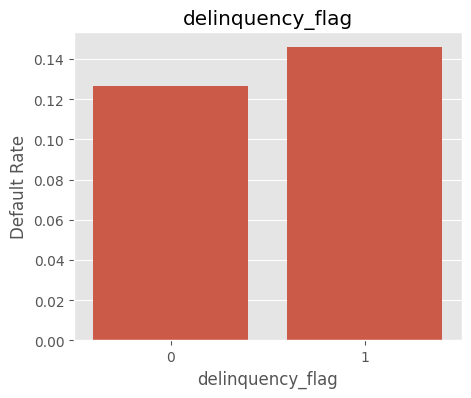

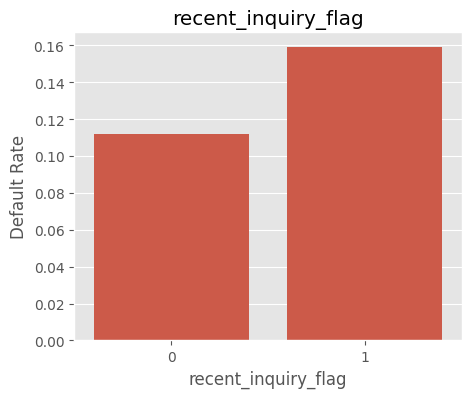

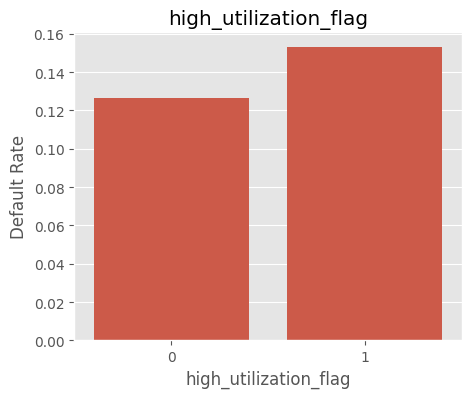

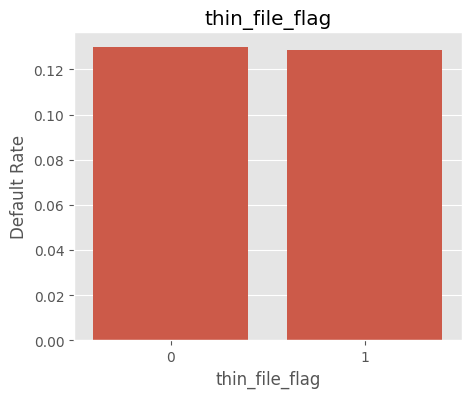

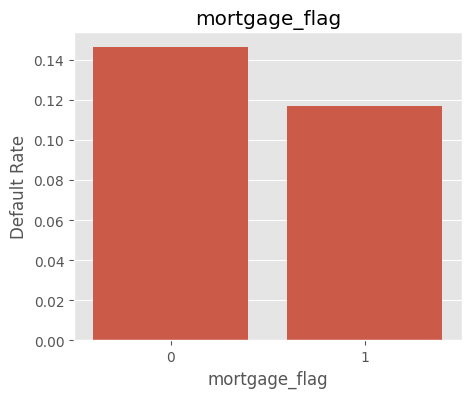

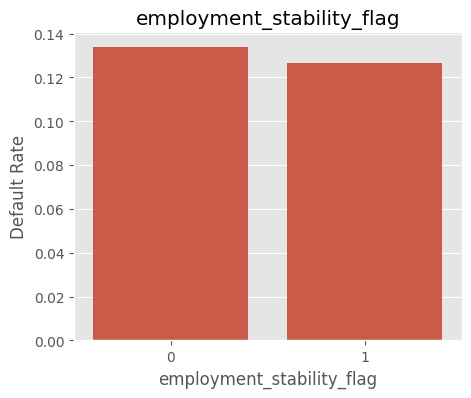

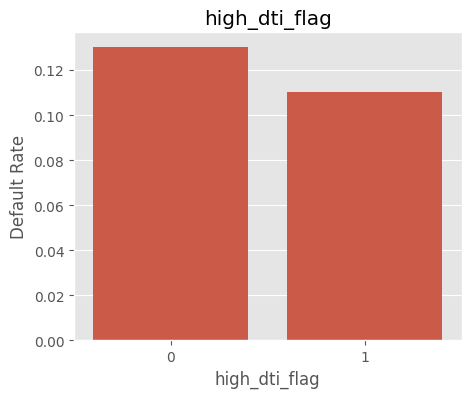

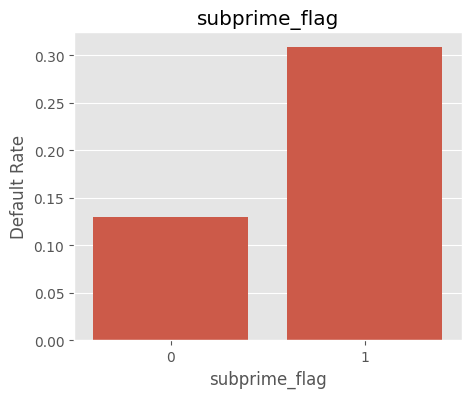

In [70]:
for feature in flag_features:

    summary = (
        df.groupby(feature)["default_flag"]
          .mean()
          .reset_index()
    )

    plt.figure(figsize=(5,4))

    sns.barplot(
        data=summary,
        x=feature,
        y="default_flag"
    )

    plt.title(feature)

    plt.ylabel("Default Rate")

    plt.show()

# 10. Imputation EDA



**Objective**

Rather than using a global mean, we want to determine whether borrower characteristics explain the missing variables.

If they do, group-wise imputation will preserve the natural distribution much better.

In [71]:
# Annual Income by Grade

income_summary = (
    df.groupby("grade")["annual_inc"]
      .agg(
          count="count",
          mean="mean",
          median="median",
          std="std"
      )
      .round(2)
)

income_summary

,count,mean,median,std
grade,,,,
A,656298,91130.74,75000.0,96647.92
B,857573,80642.17,67000.0,161024.06
C,802280,75619.00,64000.0,79516.95
D,416280,72699.32,60358.5,73874.38
E,139036,71948.77,60000.0,63369.34
F,41836,72652.15,63000.0,49033.28
G,12185,75193.11,65000.0,51014.09


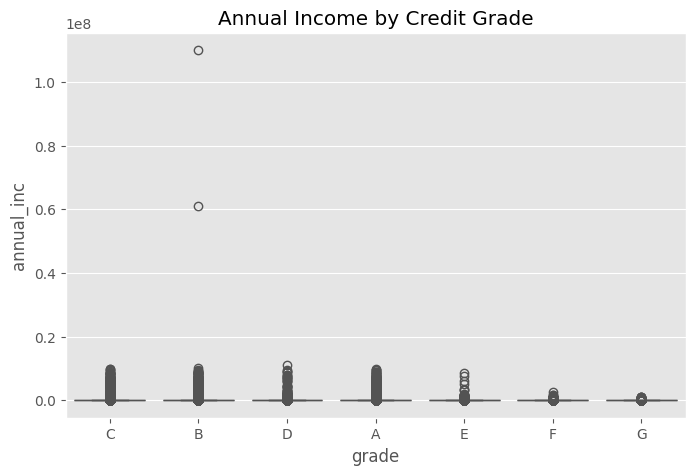

In [72]:
# visual

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="grade",
    y="annual_inc"
)

plt.title("Annual Income by Credit Grade")

plt.show()

In [73]:
# DTI by Grade

df.groupby("grade")["dti"].describe()

,count,mean,std,min,25%,50%,75%,max
grade,,,,,,,,
A,655693.0,17.107747,14.089162,0.0,10.4700,15.84,22.0900,999.0
B,856712.0,18.602412,15.460580,-1.0,11.6700,17.42,23.9200,999.0
C,801398.0,20.030115,15.598193,-1.0,12.8200,18.97,25.7200,999.0
D,415681.0,21.659948,18.063744,0.0,13.9800,20.56,27.7200,999.0
E,138924.0,21.611311,16.116041,0.0,14.2600,20.91,27.9100,999.0
F,41808.0,21.679380,13.938525,0.0,14.5900,21.17,28.0200,999.0
G,12168.0,22.432614,20.241350,0.0,14.8075,21.62,28.5625,999.0


<Axes: xlabel='grade', ylabel='dti'>

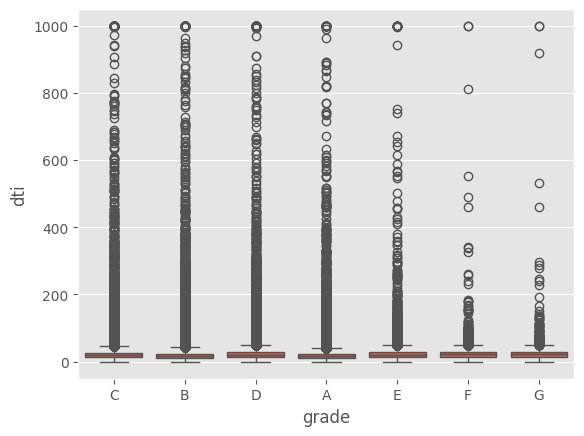

In [74]:
sns.boxplot(
    data=df,
    x="grade",
    y="dti"
)

In [75]:
# Bankcard Utilization by FICO Band

df.groupby("fico_band")["bc_util"].describe()

,count,mean,std,min,25%,50%,75%,max
fico_band,,,,,,,,
Exceptional,42826.0,9.286975,9.085729,0.0,2.5,7.1,13.4,99.5
Fair,431090.0,69.761999,25.012246,0.0,54.0,75.7,90.6,318.2
Good,2020906.0,58.875823,26.859846,0.0,38.5,60.3,82.0,339.6
Very Good,346529.0,27.245775,20.680876,0.0,12.0,23.3,37.8,201.6


<Axes: xlabel='fico_band', ylabel='bc_util'>

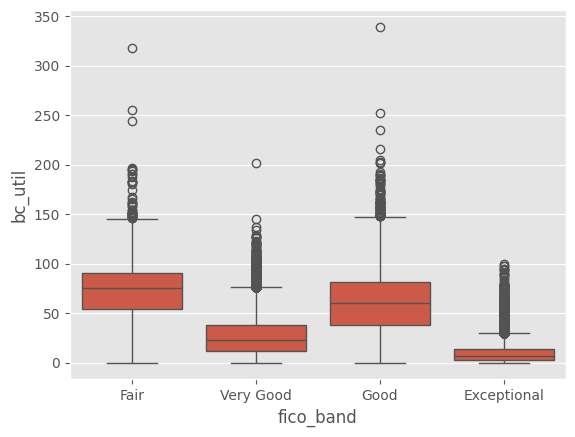

In [76]:
sns.boxplot(
    data=df,
    x="fico_band",
    y="bc_util"
)

In [77]:
# Mortgage Accounts by Home Ownership

df.groupby("home_ownership")["mort_acc"].describe()

,count,mean,std,min,25%,50%,75%,max
home_ownership,,,,,,,,
ANY,3519.0,0.981813,1.545486,0.0,0.0,0.0,2.0,10.0
MORTGAGE,1415784.0,2.460214,1.895912,0.0,1.0,2.0,3.0,94.0
NONE,47.0,1.787234,2.042336,0.0,0.0,1.0,3.0,8.0
OTHER,45.0,1.555556,2.040004,0.0,0.0,1.0,2.0,7.0
OWN,327430.0,1.156601,1.704181,0.0,0.0,0.0,2.0,52.0
RENT,1128637.0,0.428142,1.098901,0.0,0.0,0.0,0.0,30.0


<Axes: xlabel='home_ownership', ylabel='mort_acc'>

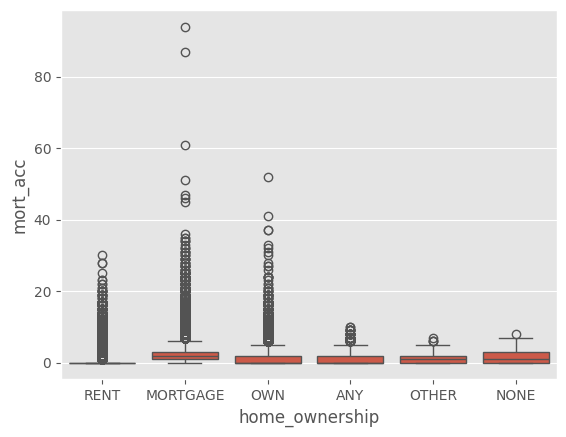

In [78]:
sns.boxplot(
    data=df,
    x="home_ownership",
    y="mort_acc"
)

In [79]:
# Revolving Utilization by FICO Band

df.groupby("fico_band")["revol_util_pct"].describe()

,count,unique,top,freq
fico_band,,,,
Exceptional,43871,610,0E-9,1761
Fair,441216,1217,0E-9,1452
Good,2075408,1370,0E-9,8495
Very Good,362337,1070,0E-9,7148


<Axes: xlabel='fico_band', ylabel='revol_util_pct'>

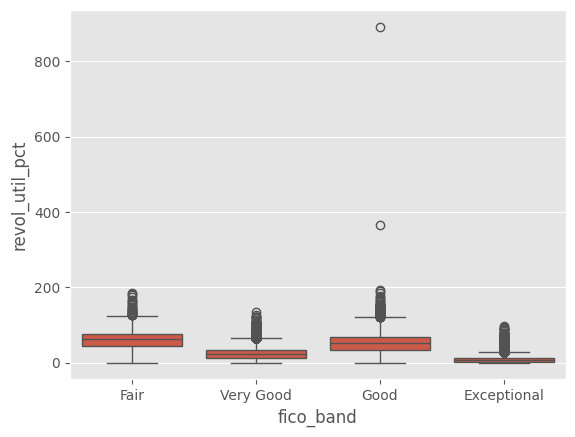

In [80]:
sns.boxplot(
    data=df,
    x="fico_band",
    y="revol_util_pct"
)

In [81]:
# Employment Length by Grade

df.groupby("grade")["emp_length_years"].describe()

,count,mean,std,min,25%,50%,75%,max
grade,,,,,,,,
A,611503.0,5.822305,3.78091,0.0,2.0,6.0,10.0,10.0
B,797047.0,5.849734,3.749834,0.0,2.0,6.0,10.0,10.0
C,745612.0,5.798858,3.750339,0.0,2.0,6.0,10.0,10.0
D,385016.0,5.789193,3.739102,0.0,2.0,6.0,10.0,10.0
E,130100.0,5.916172,3.710245,0.0,2.0,6.0,10.0,10.0
F,39471.0,6.024271,3.673875,0.0,3.0,6.0,10.0,10.0
G,11523.0,5.938992,3.706374,0.0,2.0,6.0,10.0,10.0


<Axes: xlabel='grade', ylabel='emp_length_years'>

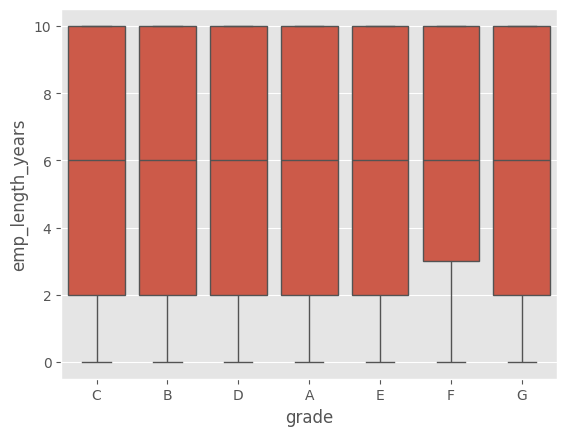

In [82]:
sns.boxplot(
    data=df,
    x="grade",
    y="emp_length_years"
)